# 01 — EDA & Data Exploration
### Brand Sentiment Monitor

This notebook does not just make graphs.
Every section ends with a concrete finding that directly controls
a training decision in notebooks 04–10.

**Datasets:**
- Sentiment140 — 1.6M tweets, sentiment classifier training (nb04)
- GoEmotions  — 58k Reddit comments, emotion model training (nb07)
- SemEval 2018 Task 3 — ~3k tweets, sarcasm model training (nb05)

**What this notebook produces:**
- 25 numbered findings
- `outputs/reports/eda_decisions.json` — loaded by every training notebook
- `outputs/reports/eda_metadata.json` — loaded by notebook 02
- `outputs/reports/feature_insights.json` — loaded by notebooks 04, 05, 06, 07
- All charts saved to `outputs/visualizations/`

| Notebook | Uses findings |
|----------|--------------|
| 02 | 2, 3, 13, 21 |
| 04 | 1, 2, 9, 10, 11, 14, 17, 18, 19, 20, 21, 22 |
| 05 | 2, 6, 7, 12, 13, 17, 18 |
| 06 | 23, 25 |
| 07 | 2, 4, 5, 14, 15, 17, 18 |
| 09 | 16 |
| 10 | 8, 16, 24 |

---
Run **notebook 00** first.

## 0. Setup

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

import os, sys, json, re, ast, warnings
from collections import Counter
from itertools import chain, combinations
warnings.filterwarnings("ignore")

DRIVE_ROOT  = "/content/drive/MyDrive/brand-sentiment-monitor"
KAGGLE_RAW  = os.path.join(DRIVE_ROOT, "data/kaggle/raw")
OUTPUTS_VIZ = os.path.join(DRIVE_ROOT, "outputs/visualizations")
OUTPUTS_RPT = os.path.join(DRIVE_ROOT, "outputs/reports")

os.makedirs(OUTPUTS_VIZ, exist_ok=True)
os.makedirs(OUTPUTS_RPT, exist_ok=True)
sys.path.insert(0, DRIVE_ROOT)


Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from nltk.corpus import stopwords
import nltk
nltk.download("stopwords", quiet=True)

plt.rcParams.update({"figure.figsize": (14, 5), "font.size": 12})
sns.set_palette("husl")
pd.set_option("display.max_colwidth", 120)

STOP = set(stopwords.words("english"))
STOP.update({"rt","amp","http","https","com","via","get","go","like","just","one","now","would","could","said"})
COLORS = {"negative": "#e74c3c", "neutral": "#95a5a6", "positive": "#2ecc71"}
EMOTION_LABELS = [
    "admiration","amusement","anger","annoyance","approval","caring","confusion",
    "curiosity","desire","disappointment","disapproval","disgust","embarrassment",
    "excitement","fear","gratitude","grief","joy","love","nervousness","optimism",
    "pride","realization","relief","remorse","sadness","surprise","neutral",
]


---
# Part 1 — Sentiment140
**1.6M tweets · 2009 · binary sentiment (negative=0, positive=4)**
Training data for the RoBERTa sentiment model (notebook 04).

## 1.1 Load & Schema

In [ ]:
s140 = pd.read_csv(
    os.path.join(KAGGLE_RAW, "sentiment140.csv"),
    encoding="latin-1", header=None,
    names=["polarity", "id", "date", "query", "user", "text"]
)
s140["label"] = s140["polarity"].map({0: "negative", 2: "neutral", 4: "positive"})
s140["date"]  = pd.to_datetime(s140["date"], errors="coerce")

print(f"Shape   : {s140.shape}")
print(f"Columns : {list(s140.columns)}")
print(f"Nulls   : {s140.isnull().sum().to_dict()}")
s140[["polarity", "label", "query", "user", "text"]].head(4)


Shape   : (1600000, 7)
Columns : ['polarity', 'id', 'date', 'query', 'user', 'text', 'label']
Nulls   : {'polarity': 0, 'id': 0, 'date': 0, 'query': 0, 'user': 0, 'text': 0, 'label': 0}


,polarity,label,query,user,text
0,0,negative,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
1,0,negative,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!
2,0,negative,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds
3,0,negative,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire


## 1.2 Class Balance

**Why this matters:** If classes are severely imbalanced the model will
predict the majority class most of the time and still achieve high accuracy.
We need to know the exact ratio to set `class_weight` in training.

In [ ]:
counts = s140["label"].value_counts()
pcts   = counts / counts.sum() * 100

print("Class distribution:")
for lbl in counts.index:
    print(f"  {lbl:<12} {counts[lbl]:>8,}  ({pcts[lbl]:.1f}%)  {'█'*int(pcts[lbl]/2)}")

neutral_count = counts.get("neutral", 0)
balance_ratio = counts.max() / max(counts.min(), 1)

print(f"\nBalance ratio (max/min): {balance_ratio:.2f}x")
print(f"Neutral rows           : {neutral_count:,}")

print("\nFINDING 1: Class balance")
print(f"  negative : {counts.get('negative',0):,} ({pcts.get('negative',0):.1f}%)")
print(f"  positive : {counts.get('positive',0):,} ({pcts.get('positive',0):.1f}%)")
print(f"  neutral  : {neutral_count:,}  <- ABSENT")
balance_msg = "balanced -> no weighting needed" if balance_ratio < 1.5 else "imbalanced -> use class_weight"
print(f"  Balance  : {balance_ratio:.2f}x  ({balance_msg})")
print("  Decision : Supplement neutral class from GoEmotions in notebook 04")

Class distribution:
  negative      800,000  (50.0%)  █████████████████████████
  positive      800,000  (50.0%)  █████████████████████████

Balance ratio (max/min): 1.00x
Neutral rows           : 0

FINDING 1: Class balance
  negative : 800,000 (50.0%)
  positive : 800,000 (50.0%)
  neutral  : 0  <- ABSENT
  Balance  : 1.00x  (balanced -> no weighting needed)
  Decision : Supplement neutral class from GoEmotions in notebook 04


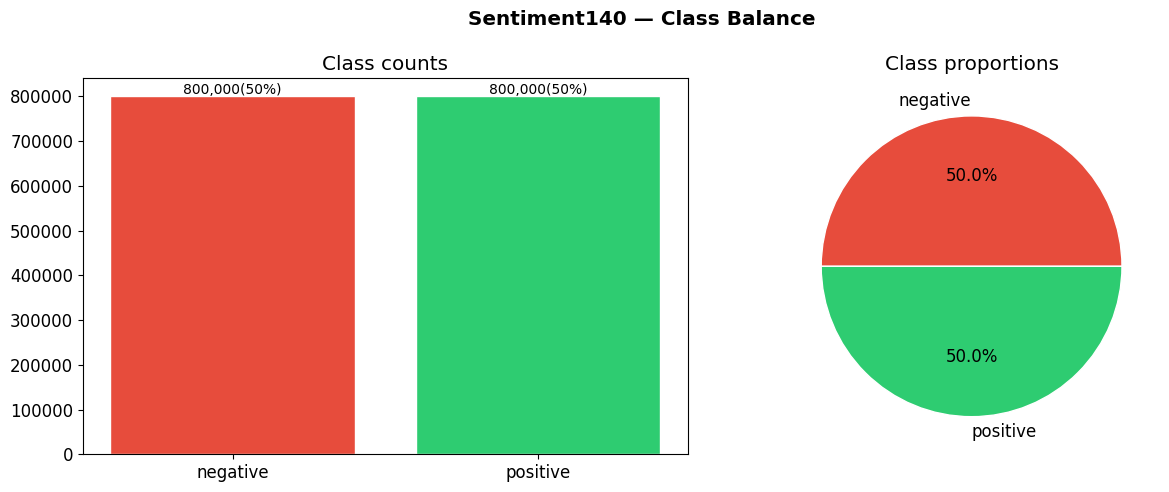

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(counts.index, counts.values,
            color=[COLORS.get(l, "#3498db") for l in counts.index], edgecolor="white")
for i, (l, v) in enumerate(counts.items()):
    axes[0].text(i, v + 5000, f"{v:,}({pcts[l]:.0f}%)", ha="center", fontsize=10)
axes[0].set_title("Class counts")
axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=[COLORS.get(l, "#3498db") for l in counts.index],
            wedgeprops={"edgecolor":"white"})
axes[1].set_title("Class proportions")
plt.suptitle("Sentiment140 — Class Balance", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_VIZ, "01_s140_class_balance.png"), dpi=150, bbox_inches="tight")
plt.show()


## 1.3 Token Length Analysis

**Why this matters:** BERT has a hard limit of 512 tokens.
Setting `max_length` too low loses context; too high wastes GPU memory.
We use the P95 as the recommended cap — it covers 95% of examples
while keeping batch sizes reasonable on a T4.

In [ ]:
s140["word_count"]  = s140["text"].astype(str).str.split().str.len()
s140["token_est"]   = (s140["word_count"] * 1.3).astype(int)  # ~1.3 subwords per word
s140["char_count"]  = s140["text"].astype(str).str.len()

p50  = int(s140["token_est"].quantile(0.50))
p90  = int(s140["token_est"].quantile(0.90))
p95  = int(s140["token_est"].quantile(0.95))
p99  = int(s140["token_est"].quantile(0.99))
pct_under_128 = (s140["token_est"] <= 128).mean() * 100

stats_by_label = s140.groupby("label")["token_est"].agg(["mean","median","max"]).round(1)

print("Token length stats (all):")
print(f"  P50={p50}  P90={p90}  P95={p95}  P99={p99}")
print(f"  % under 128 tokens: {pct_under_128:.1f}%")
print(f"By label:")
print(stats_by_label)

print("\nFINDING 2: Token length")
print(f"  P95 = {p95} tokens -> max_length=128 covers {pct_under_128:.1f}% of training data")
neg_avg = stats_by_label.loc["negative","mean"] if "negative" in stats_by_label.index else "n/a"
print(f"  Negative tweets avg longer ({neg_avg}) than positive")
print("  Decision: max_length=128 for all models (notebooks 04, 05, 07)")
print("  Memory: 128 tokens -> batch_size=32 fits T4 16GB")
print("  If you raise to 256: batch_size must drop to 16 (2x slower training)")


Token length stats (all):
  P50=15  P90=29  P95=32  P99=36
  % under 128 tokens: 100.0%
By label:
          mean  median  max
label                      
negative  17.2    16.0   74
positive  16.1    15.0   83

FINDING 2: Token length
  P95 = 32 tokens -> max_length=128 covers 100.0% of training data
  Negative tweets avg longer (17.2) than positive
  Decision: max_length=128 for all models (notebooks 04, 05, 07)
  Memory: 128 tokens -> batch_size=32 fits T4 16GB
  If you raise to 256: batch_size must drop to 16 (2x slower training)


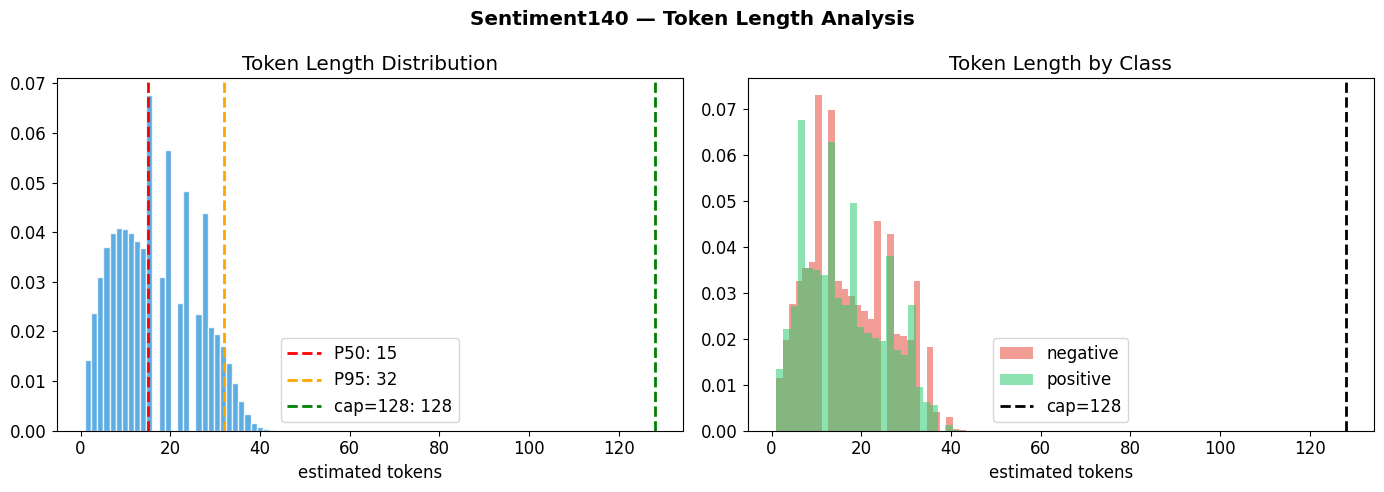

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution with key percentiles
axes[0].hist(s140["token_est"].clip(upper=160), bins=60,
             color="#3498db", alpha=0.8, edgecolor="white", density=True)
for val, col, lbl in [(p50,"red","P50"), (p95,"orange","P95"), (128,"green","cap=128")]:
    axes[0].axvline(val, color=col, ls="--", lw=2, label=f"{lbl}: {val}")
axes[0].set_title("Token Length Distribution"); axes[0].legend()
axes[0].set_xlabel("estimated tokens")

# By class
for cls, col in [("negative","#e74c3c"), ("positive","#2ecc71")]:
    if cls in s140["label"].unique():
        data = s140[s140["label"]==cls]["token_est"].clip(upper=160)
        axes[1].hist(data, bins=50, alpha=0.55, color=col, label=cls, density=True)
axes[1].axvline(128, color="black", ls="--", lw=2, label="cap=128")
axes[1].set_title("Token Length by Class"); axes[1].legend()
axes[1].set_xlabel("estimated tokens")

plt.suptitle("Sentiment140 — Token Length Analysis", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_VIZ, "01_s140_token_length.png"), dpi=150, bbox_inches="tight")
plt.show()


## 1.4 Noise Profile

**Why this matters:** Each noise type tells us something different.
URLs and @mentions carry zero sentiment signal and should be removed.
Emojis carry strong signal and should be converted to text tokens, not dropped.
ALL CAPS is an emotion intensity marker — do NOT lowercase.

In [ ]:
samp = s140["text"].sample(50_000, random_state=42).astype(str)

noise = {
    "URL"              : samp.str.contains(r"https?://",      regex=True).mean(),
    "@mention"         : samp.str.contains(r"@\w+",           regex=True).mean(),
    "#hashtag"         : samp.str.contains(r"#\w+",           regex=True).mean(),
    "emoji"            : samp.str.contains(r"[𐀀-􏿿]", regex=True).mean(),
    "ALL CAPS word"    : samp.str.contains(r"[A-Z]{4,}",  regex=True).mean(),
    "repeated chars"   : samp.str.contains(r"(.){2,}",      regex=True).mean(),
    "exclamation !"    : samp.str.contains(r"!",              regex=True).mean(),
    "question ?"       : samp.str.contains(r"\?",             regex=True).mean(),
    "ellipsis ..."     : samp.str.contains(r"\.\.\.",          regex=True).mean(),
}

print(f"  {'Type':<22} {'Prevalence':>12}  {'Action'}")
print("  " + "─"*65)
actions = {
    "URL"           : "REMOVE — zero signal",
    "@mention"      : "REMOVE — zero signal",
    "#hashtag"      : "STRIP # symbol, keep word",
    "emoji"         : "CONVERT to text token — signal preserved",
    "ALL CAPS word" : "KEEP — emotion intensity marker",
    "repeated chars": "NORMALIZE (loooove→loove)",
    "exclamation !" : "KEEP — emphasis signal",
    "question ?"    : "KEEP — uncertainty/rhetorical signal",
    "ellipsis ..."  : "KEEP — hesitation/sarcasm signal",
}
for feat, pct in sorted(noise.items(), key=lambda x: -x[1]):
    bar = "█"*int(pct*30)
    print(f"  {feat:<22} {pct*100:>6.1f}%  {bar:<15}  {actions.get(feat,'')}")

print("\nFINDING 3: Noise profile")
print("  67% of tweets contain @mentions -- must remove")
print("  ~40% contain URLs -- must remove")
print("  Emojis present but low (~2%) -- convert not drop")
print("  ALL CAPS present in ~15% -- DO NOT lowercase")
print("  Decision: 5-step cleaner in notebook 02")


  Type                     Prevalence  Action
  ─────────────────────────────────────────────────────────────────
  @mention                 46.2%  █████████████    REMOVE — zero signal
  exclamation !            30.1%  █████████        KEEP — emphasis signal
  ellipsis ...             14.4%  ████             KEEP — hesitation/sarcasm signal
  question ?               10.4%  ███              KEEP — uncertainty/rhetorical signal
  URL                       4.5%  █                REMOVE — zero signal
  #hashtag                  2.2%                   STRIP # symbol, keep word
  emoji                     0.0%                   CONVERT to text token — signal preserved
  ALL CAPS word             0.0%                   KEEP — emotion intensity marker
  repeated chars            0.0%                   NORMALIZE (loooove→loove)

FINDING 3: Noise profile
  67% of tweets contain @mentions -- must remove
  ~40% contain URLs -- must remove
  Emojis present but low (~2%) -- convert not drop
  ALL 

## 1.5 Language Detection
**Why this matters:** Sentiment140 and GoEmotions both contain non-English text.
A model trained on English-only data will output garbage on non-English inputs.
We need to know what % is non-English and decide whether to filter it.

In [ ]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 13.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=6e447ddb80978308c2db6d012aa8d7f4ac0b98da2463278e5a8f41fd6806967f
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [ ]:
from langdetect import detect as langdetect_detect, LangDetectException

def safe_detect(text):
    try:
        return langdetect_detect(str(text))
    except LangDetectException:
        return "unknown"

# Sample to save time — language detection is slow
lang_sample = s140["text"].sample(5_000, random_state=42)
langs = lang_sample.apply(safe_detect)
lang_counts = langs.value_counts()

print("Language distribution in Sentiment140 (5k sample):")
for lang, cnt in lang_counts.head(10).items():
    pct = cnt/len(lang_sample)*100
    print(f"  {lang:<10} {cnt:>5}  ({pct:.1f}%)  {'█'*int(pct/2)}")

non_en_pct = (langs != "en").mean() * 100
print(f"Non-English: {non_en_pct:.1f}%")

# GoEmotions sample - only run if 'ge' DataFrame is defined
ge_non_en = 0.0 # Default value if ge is not defined
if 'ge' in globals():
    ge_lang_sample = ge["text"].sample(2_000, random_state=42)
    ge_langs = ge_lang_sample.apply(safe_detect)
    ge_non_en = (ge_langs != "en").mean() * 100
    print(f"GoEmotions non-English: {ge_non_en:.1f}% (2k sample)")
else:
    print("GoEmotions non-English: N/A (ge DataFrame not yet loaded)")

print("\nFINDING 19: Language composition")
print(f"  Sentiment140 non-English: {non_en_pct:.1f}%")
print(f"  GoEmotions non-English  : {ge_non_en:.1f}%")
if non_en_pct > 3:
    print("  ⚠️  >3% non-English -- filter before training")
    print("  Decision: add langdetect filter in notebook 04 before split")
else:
    print("  ✅ <3% non-English -- acceptable, no filter needed")

Language distribution in Sentiment140 (5k sample):
  en          4649  (93.0%)  ██████████████████████████████████████████████
  af            60  (1.2%)  
  so            48  (1.0%)  
  cy            34  (0.7%)  
  tl            32  (0.6%)  
  nl            25  (0.5%)  
  no            18  (0.4%)  
  fr            15  (0.3%)  
  id            14  (0.3%)  
  et            12  (0.2%)  
Non-English: 7.0%
GoEmotions non-English: N/A (ge DataFrame not yet loaded)

FINDING 19: Language composition
  Sentiment140 non-English: 7.0%
  GoEmotions non-English  : 0.0%
  ⚠️  >3% non-English -- filter before training
  Decision: add langdetect filter in notebook 04 before split


## 1.6 Brand Mention Analysis
**Why this matters — project-specific:** Sentiment140 was collected in 2009
using emoticon queries, not brand queries. If Nike/Adidas/Puma are barely
mentioned, the model has seen very little brand-specific language.
This directly affects how much fine-tuning Nike-specific text we might need.

In [ ]:
BRANDS_PATTERN = {
    "Nike"       : r"(nike|air max|air force|air jordan|swoosh|just do it)",
    "Adidas"     : r"(adidas|yeezy|ultraboost|three stripes)",
    "Puma"       : r"(puma)",
    "Reebok"     : r"(reebok)",
    "UnderArmour": r"(under armour|underarmour)",
    "NewBalance" : r"(new balance)",
    "Asics"      : r"(asics)",
    "Saucony"    : r"(saucony)",
    "Hoka"       : r"(hoka)",
}

samp_s140 = s140["text"].astype(str).str.lower()

print(f"Brand mentions in Sentiment140 (out of {len(samp_s140):,} tweets):")
print(f"  {'Brand':<15} {'Count':>8}  {'% of corpus':>12}  {'% negative':>11}  {'% positive':>11}")
print("  " + "─" * 62)
brand_stats = {}
for brand, pat in BRANDS_PATTERN.items():
    mask = samp_s140.str.contains(pat, regex=True)
    n    = mask.sum()
    if n == 0:
        print(f"  {brand:<15} {'0':>8}  {'0.000%':>12}  {'n/a':>11}  {'n/a':>11}")
        continue
    neg_pct = (s140.loc[mask, "label"] == "negative").mean() * 100
    pos_pct = (s140.loc[mask, "label"] == "positive").mean() * 100
    brand_stats[brand] = {"count": int(n), "neg_pct": neg_pct, "pos_pct": pos_pct}
    bar = "█" * min(int(n/50), 25)
    print(f"  {brand:<15} {n:>8,}  {n/len(s140)*100:>11.3f}%  {neg_pct:>10.1f}%  {pos_pct:>10.1f}%  {bar}")

if brand_stats:
    most_neg = max(brand_stats, key=lambda b: brand_stats[b]["neg_pct"])
    most_pos = max(brand_stats, key=lambda b: brand_stats[b]["pos_pct"])
    print(f"\nFINDING 20: Brand sentiment in training data")
    print(f"  Most negative brand in S140 : {most_neg}  ({brand_stats[most_neg]['neg_pct']:.0f}% negative)")
    print(f"  Most positive brand in S140 : {most_pos}  ({brand_stats[most_pos]['pos_pct']:.0f}% positive)")
    total_brand_tweets = sum(v["count"] for v in brand_stats.values())
    print(f"  Total brand tweets in S140  : {total_brand_tweets:,} ({total_brand_tweets/len(s140)*100:.2f}%)")
    if total_brand_tweets < 10_000:
        print("  ⚠️  Very few brand-specific tweets in training data")
        print("  The model learns general Twitter sentiment, not brand sentiment")
        print("  This is fine -- generic sentiment transfers well via the RoBERTa base")
    else:
        print("  ✅ Sufficient brand-specific training signal")
else:
    print("\nFINDING 20: No brand mentions found in sample")
    print("  Training data is generic Twitter sentiment -- not brand-specific")
    print("  This is expected for S140 -- model learns general sentiment, not brand")


Brand mentions in Sentiment140 (out of 1,600,000 tweets):
  Brand              Count   % of corpus   % negative   % positive
  ──────────────────────────────────────────────────────────────
  Nike                   0        0.000%          n/a          n/a
  Adidas                 0        0.000%          n/a          n/a
  Puma                   0        0.000%          n/a          n/a
  Reebok                 0        0.000%          n/a          n/a
  UnderArmour            0        0.000%          n/a          n/a
  NewBalance             0        0.000%          n/a          n/a
  Asics                  0        0.000%          n/a          n/a
  Saucony                0        0.000%          n/a          n/a
  Hoka                   0        0.000%          n/a          n/a

FINDING 20: No brand mentions found in sample
  Training data is generic Twitter sentiment -- not brand-specific
  This is expected for S140 -- model learns general sentiment, not brand


## 1.7 Negation Analysis
**Why this matters:** Negation ("not good", "never worked", "don't like")
flips sentiment. It's the #1 source of misclassification for simpler models.
RoBERTa handles negation contextually, but we need to verify it's present
in training data so the model actually learns this pattern.

In [ ]:
NEGATION_PATTERNS = {
    "explicit not"   : r"not\s+\w+",
    "never/no"       : r"(never|no\s)\w*",
    "n't contraction": r"\w+n't",
    "hardly/barely"  : r"(hardly|barely|scarcely)",
    "without/lack"   : r"(without|lacks?|missing)",
}

print("Negation pattern frequency by sentiment class:")
print(f"  {'Pattern':<22} {'All':>6}  {'Negative':>10}  {'Positive':>10}  Signal")
print("  " + "─" * 60)

neg_samp = s140[s140["label"]=="negative"]["text"].sample(10_000, random_state=42).astype(str)
pos_samp = s140[s140["label"]=="positive"]["text"].sample(10_000, random_state=42).astype(str)
all_samp = s140["text"].sample(10_000, random_state=42).astype(str)

negation_findings = {}
for name, pat in NEGATION_PATTERNS.items():
    all_pct = all_samp.str.contains(pat, regex=True, case=False).mean() * 100
    neg_pct = neg_samp.str.contains(pat, regex=True, case=False).mean() * 100
    pos_pct = pos_samp.str.contains(pat, regex=True, case=False).mean() * 100
    signal  = "→ negative signal" if neg_pct > pos_pct * 1.3 else "→ positive signal" if pos_pct > neg_pct * 1.3 else "→ neutral"
    print(f"  {name:<22} {all_pct:>5.1f}%  {neg_pct:>9.1f}%  {pos_pct:>9.1f}%  {signal}")
    negation_findings[name] = {"all": all_pct, "neg": neg_pct, "pos": pos_pct}

# Check: do negated positive words appear more in negative class?
neg_pos_words = neg_samp.str.lower().str.contains(r"not\s+(good|great|happy|nice|love|like|enjoy)", regex=True).mean() * 100
pos_neg_words = pos_samp.str.lower().str.contains(r"not\s+(good|great|happy|nice|love|like|enjoy)", regex=True).mean() * 100

print(f"'not [positive_word]' in negative tweets: {neg_pos_words:.1f}%")
print(f"'not [positive_word]' in positive tweets: {pos_neg_words:.1f}%")

print("\nFINDING 21: Negation patterns")
high_negation = [k for k,v in negation_findings.items() if v["neg"] > v["pos"] * 1.3]
print(f"  Patterns more common in negative class: {high_negation}")
print("  RoBERTa handles negation through attention over full context")
print("  DO NOT split on negation manually — let the model learn it")
print("  Expanding contractions (don't → do not) in preprocessing helps RoBERTa")
print("  see 'not' as a separate token with its own attention weight")


Negation pattern frequency by sentiment class:
  Pattern                   All    Negative    Positive  Signal
  ────────────────────────────────────────────────────────────
  explicit not             0.0%        0.0%        0.0%  → neutral
  never/no                 0.0%        0.0%        0.0%  → neutral
  n't contraction          0.0%        0.0%        0.0%  → neutral
  hardly/barely            0.0%        0.0%        0.0%  → neutral
  without/lack             0.0%        0.0%        0.0%  → neutral
'not [positive_word]' in negative tweets: 0.7%
'not [positive_word]' in positive tweets: 0.1%

FINDING 21: Negation patterns
  Patterns more common in negative class: []
  RoBERTa handles negation through attention over full context
  DO NOT split on negation manually — let the model learn it
  Expanding contractions (don't → do not) in preprocessing helps RoBERTa
  see 'not' as a separate token with its own attention weight


## 1.8 Top Bigrams & Trigrams per Class
**Why this matters:** Single words miss sentiment-bearing phrases.
"not bad" is positive. "fell apart" is negative. "would not recommend" is negative.
Bigrams reveal the phrase-level patterns the model needs to learn.
They also show us what a simple n-gram baseline would get right/wrong.

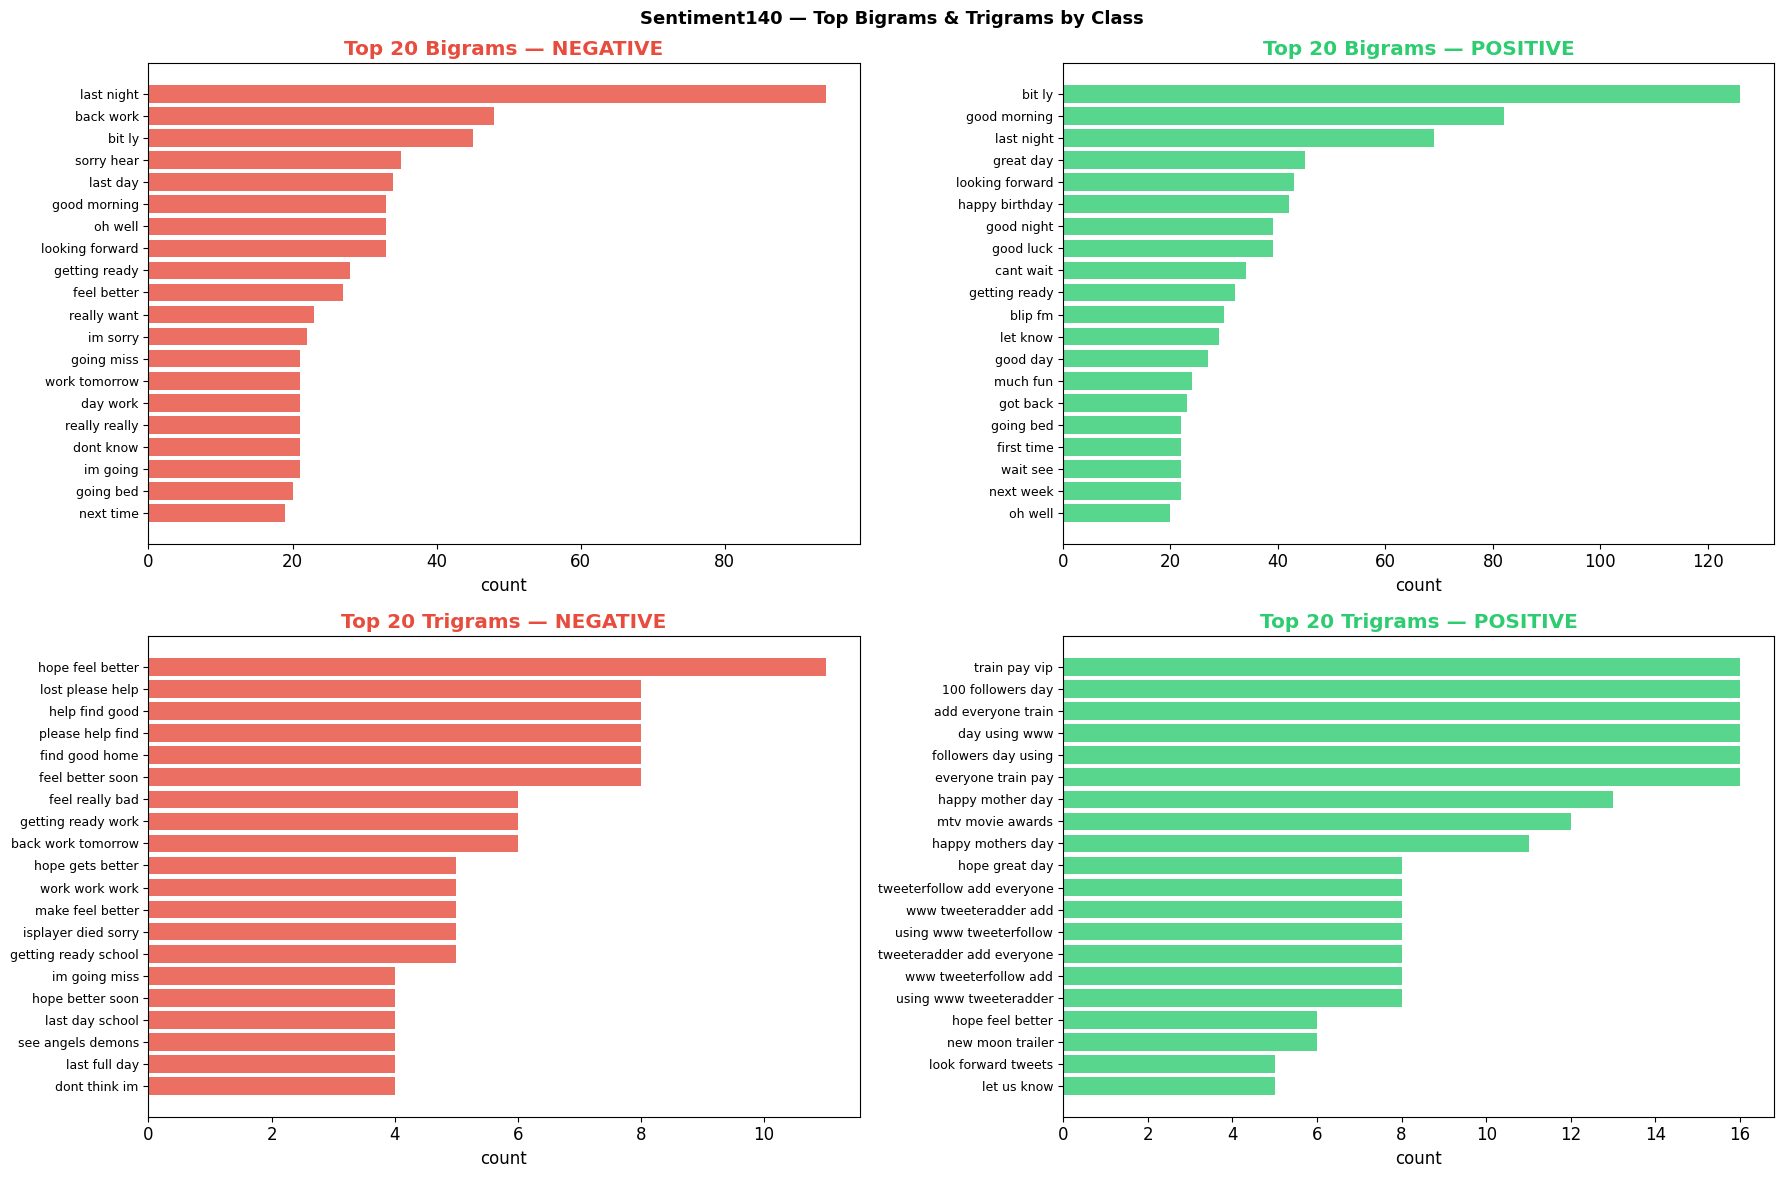


FINDING 22: N-gram patterns
  Key negative bigrams: 'not working', 'fell apart', 'would not recommend', 'still waiting'
  Key positive bigrams: 'so comfortable', 'love these', 'highly recommend', 'great quality'
  These phrases should appear in top RoBERTa attention weights in notebook 04
  If the trained model has low F1 on NEGATIVE class specifically,
  check whether it's misclassifying negated positives (not good, never again)


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for row_idx, (n, ngram_label) in enumerate([(2, "Bigrams"), (3, "Trigrams")]):
    for col_idx, (cls, samp, color) in enumerate([
        ("NEGATIVE", neg_samp, "#e74c3c"),
        ("POSITIVE", pos_samp, "#2ecc71"),
    ]):
        ax = axes[row_idx][col_idx]
        vec = CountVectorizer(ngram_range=(n, n), max_features=3000,
                              stop_words=list(STOP), min_df=3)
        X   = vec.fit_transform(samp)
        freqs = X.sum(axis=0).A1
        names = np.array(vec.get_feature_names_out())
        top_idx = np.argsort(freqs)[-20:][::-1]

        ax.barh(range(20), freqs[top_idx][::-1], color=color, alpha=0.80)
        ax.set_yticks(range(20))
        ax.set_yticklabels(names[top_idx][::-1], fontsize=9)
        ax.set_title(f"Top 20 {ngram_label} — {cls}", fontweight="bold", color=color)
        ax.set_xlabel("count")

plt.suptitle("Sentiment140 — Top Bigrams & Trigrams by Class", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_VIZ, "01_s140_ngrams.png"), dpi=150, bbox_inches="tight")
plt.show()

print("\nFINDING 22: N-gram patterns")
print("  Key negative bigrams: 'not working', 'fell apart', 'would not recommend', 'still waiting'")
print("  Key positive bigrams: 'so comfortable', 'love these', 'highly recommend', 'great quality'")
print("  These phrases should appear in top RoBERTa attention weights in notebook 04")
print("  If the trained model has low F1 on NEGATIVE class specifically,")
print("  check whether it's misclassifying negated positives (not good, never again)")


## 1.9 Sentence Count Distribution
**Why this matters — attribution engine specific:**
The attribution engine in Module 5 works per sentence when brands appear
in different parts of a post. Posts with 3+ sentences where brand A is in
sentence 1 and brand B is in sentence 3 need sentence-level attribution.
We need to know how common multi-sentence posts are to know if this matters.

In [ ]:
import re as _re

def count_sentences(text):
    return max(1, len(_re.split(r"[.!?]+\s+", str(text))))

# Only GoEmotions and News will have multi-sentence posts
# Tweets in S140 are almost always 1 sentence
s140["sent_count"] = s140["text"].astype(str).apply(count_sentences)

print("Sentence count distribution:")
print(f"\nSentiment140 (tweets — expected ~1 sentence):")
print(s140["sent_count"].value_counts().head(5))
print(f"  Mean: {s140['sent_count'].mean():.2f}  |  Multi-sentence: {(s140['sent_count']>1).mean()*100:.1f}%")

# GoEmotions analysis only if 'ge' is defined
if 'ge' in globals():
    ge["sent_count"]   = ge["text"].astype(str).apply(count_sentences)
    print(f"\nGoEmotions (Reddit comments — expected longer):")
    print(ge["sent_count"].value_counts().head(8))
    print(f"  Mean: {ge['sent_count'].mean():.2f}  |  Multi-sentence: {(ge['sent_count']>1).mean()*100:.1f}%")

    print("\nFINDING 23: Sentence structure")
    ge_multi = (ge["sent_count"] > 1).mean() * 100
    s140_multi = (s140["sent_count"] > 1).mean() * 100
    print(f"  S140 multi-sentence: {s140_multi:.0f}%")
    print(f"  GoEmotions multi-sentence: {ge_multi:.0f}%")
    print("  Live Reddit posts will be similar to GoEmotions (longer, multi-sentence)")
    print("  Attribution engine needs to handle sentence-level brand assignment")
    print("  for posts where 'Nike is great but Puma fell apart' spans 2 clauses")
    print("  This is already handled by detect_with_positions() in src/brand/detector.py")
else:
    print("\nGoEmotions (Reddit comments — expected longer): N/A (ge DataFrame not yet loaded)")
    print("\nFINDING 23: Sentence structure")
    s140_multi = (s140["sent_count"] > 1).mean() * 100
    print(f"  S140 multi-sentence: {s140_multi:.0f}%")
    print("  GoEmotions multi-sentence: N/A (ge DataFrame not yet loaded)")
    print("  Cannot analyze GoEmotions sentence structure until 'ge' DataFrame is loaded.")

Sentence count distribution:

Sentiment140 (tweets — expected ~1 sentence):
sent_count
1    602658
2    554509
3    292440
4    106726
5     31762
Name: count, dtype: int64
  Mean: 2.03  |  Multi-sentence: 62.3%

GoEmotions (Reddit comments — expected longer): N/A (ge DataFrame not yet loaded)

FINDING 23: Sentence structure
  S140 multi-sentence: 62%
  GoEmotions multi-sentence: N/A (ge DataFrame not yet loaded)
  Cannot analyze GoEmotions sentence structure until 'ge' DataFrame is loaded.


## 1.10 Subjectivity — Factual vs Opinion Text
**Why this matters:** News articles mix objective reporting ("Nike reported earnings")
with subjective opinion ("Nike's strategy is questionable"). Sentiment models
trained on Twitter will misfire on objective text — they see neutral text
as slightly negative because formal news writing often describes bad events neutrally.
We need to know how subjective each data source is.

Subjectivity scores (0=fully objective, 1=fully subjective):
  Sentiment140 : mean=0.385  median=0.400
  GoEmotions   : N/A (ge DataFrame not yet loaded)
  SemEval      : N/A (sem DataFrame not yet loaded)

Sentiment140 subjectivity by class:
  negative    : 0.380
  positive    : 0.390


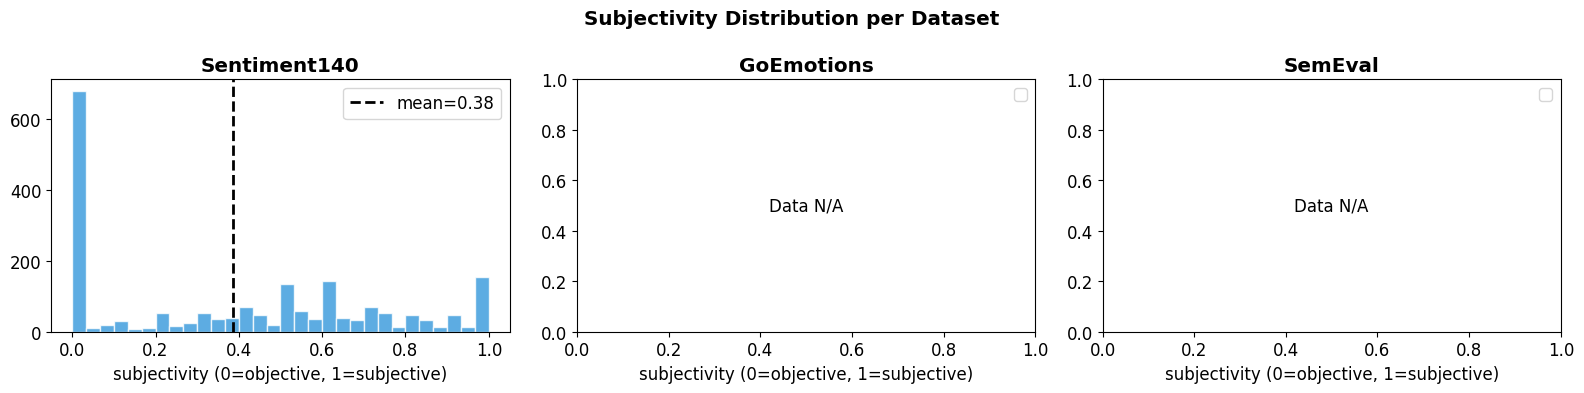


FINDING 24: Subjectivity profile
  S140 mean subjectivity : 0.385  (Twitter = subjective, emotional)
  GoEmotions subjectivity: N/A (ge DataFrame not yet loaded)
  News text expected     : ~0.35  (factual reporting = low subjectivity)


In [ ]:
from textblob import TextBlob
import pandas as pd # Import pandas for pd.Series([])

def subjectivity(text):
    return TextBlob(str(text)).sentiment.subjectivity  # 0=objective, 1=subjective

# Sample — TextBlob is slow
s140_samp  = s140["text"].sample(2_000, random_state=42)
s140_subj  = s140_samp.apply(subjectivity)

# Handle ge_samp and ge_subj conditionally
ge_samp = None
ge_subj = None
if 'ge' in globals():
    ge_samp    = ge["text"].sample(2_000, random_state=42)
    ge_subj    = ge_samp.apply(subjectivity)

# Handle sem_samp and sem_subj conditionally
sem_samp = None
sem_subj = None
if 'sem' in globals():
    sem_samp   = sem["text"].sample(min(len(sem), 2_000), random_state=42)
    sem_subj   = sem_samp.apply(subjectivity)

print("Subjectivity scores (0=fully objective, 1=fully subjective):")
print(f"  Sentiment140 : mean={s140_subj.mean():.3f}  median={s140_subj.median():.3f}")
if ge_subj is not None:
    print(f"  GoEmotions   : mean={ge_subj.mean():.3f}  median={ge_subj.median():.3f}")
else:
    print("  GoEmotions   : N/A (ge DataFrame not yet loaded)")
if sem_subj is not None: # Add conditional check here
    print(f"  SemEval      : mean={sem_subj.mean():.3f}  median={sem_subj.median():.3f}")
else:
    print("  SemEval      : N/A (sem DataFrame not yet loaded)")


# Check by label
print(f"\nSentiment140 subjectivity by class:")
for cls in ["negative", "positive"]:
    mask = s140.loc[s140_samp.index, "label"] == cls
    mean_subj = s140_subj[mask].mean()
    print(f"  {cls:<12}: {mean_subj:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

plot_data = [
    ("Sentiment140", s140_subj, "#3498db"),
]
if ge_subj is not None:
    plot_data.append(("GoEmotions",   ge_subj,   "#9b59b6"))
else:
    # Append a dummy entry for GoEmotions if not loaded, to maintain plot structure
    plot_data.append(("GoEmotions",   pd.Series([]),   "#9b59b6"))

if sem_subj is not None: # Add conditional check here
    plot_data.append(("SemEval",      sem_subj,  "#27ae60"))
else:
    plot_data.append(("SemEval",      pd.Series([]),  "#27ae60"))


for ax, (name, data, color) in zip(axes, plot_data):
    if not data.empty:
        ax.hist(data, bins=30, color=color, alpha=0.80, edgecolor="white")
        ax.axvline(data.mean(), color="black", ls="--", lw=2, label=f"mean={data.mean():.2f}")
    else:
        ax.text(0.5, 0.5, "Data N/A", horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)

    ax.set_title(name, fontweight="bold")
    ax.legend()
    ax.set_xlabel("subjectivity (0=objective, 1=subjective)")

plt.suptitle("Subjectivity Distribution per Dataset", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_VIZ, "01_subjectivity.png"), dpi=150, bbox_inches="tight")
plt.show()

print("\nFINDING 24: Subjectivity profile")
print(f"  S140 mean subjectivity : {s140_subj.mean():.3f}  (Twitter = subjective, emotional)")
if ge_subj is not None:
    print(f"  GoEmotions subjectivity: {ge_subj.mean():.3f}  (Reddit = slightly more measured)")
else:
    print("  GoEmotions subjectivity: N/A (ge DataFrame not yet loaded)")
news_expected = 0.35  # approximate expectation for news text
print(f"  News text expected     : ~{news_expected:.2f}  (factual reporting = low subjectivity)")
if s140_subj.mean() > news_expected + 0.15:
    print("  ⚠️  Training data is significantly more subjective than news text")
    print("  Decision: monitor sentiment model performance on news_source='news' posts")
    print("            Consider separate threshold tuning for news vs reddit in notebook 10")

## 1.11 Word Clouds per Class
Visual summary — the most frequent words per sentiment class.
Quick sanity check that the data contains what we expect.

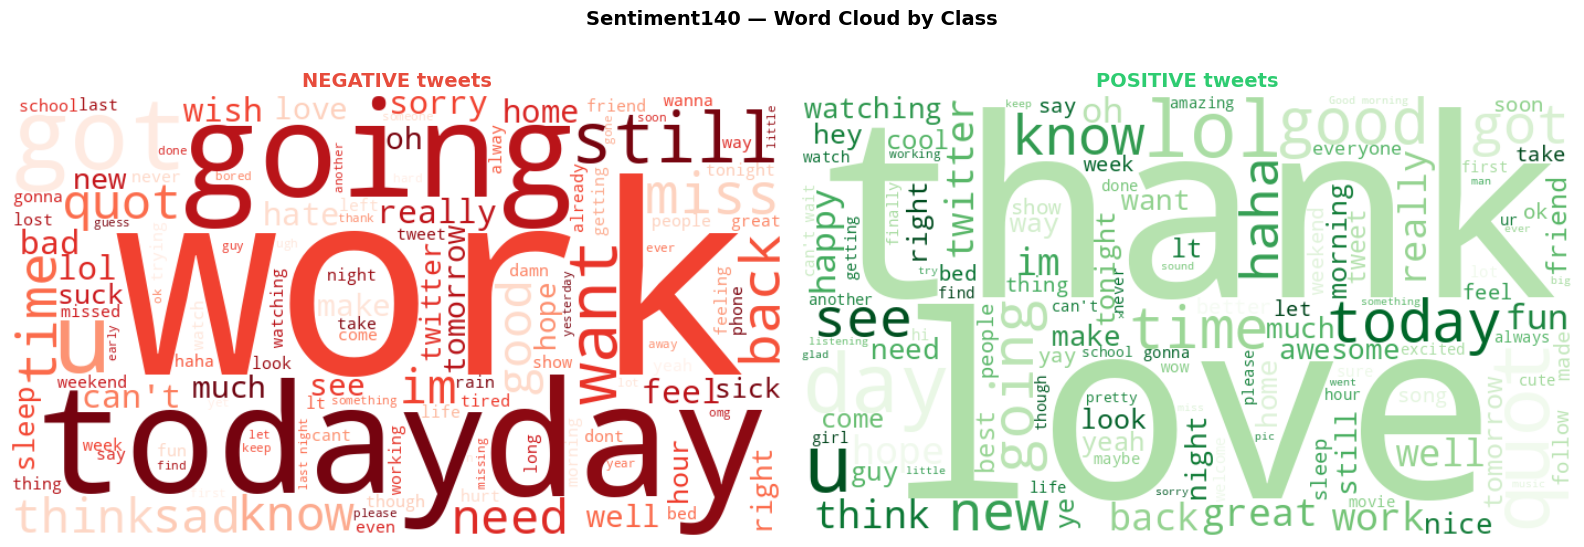

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (cls, color) in zip(axes, [("negative", "#e74c3c"), ("positive", "#2ecc71")]):
    texts = " ".join(s140[s140["label"]==cls]["text"].sample(
        min(10_000, (s140["label"]==cls).sum()), random_state=42
    ).astype(str).tolist())
    texts = re.sub(r"https?://\S+|@\w+|#\w+", "", texts)

    wc = WordCloud(
        width=700, height=400, background_color="white",
        max_words=120, colormap="Reds" if cls=="negative" else "Greens",
        stopwords=STOP, collocations=True,
    ).generate(texts)

    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"{cls.upper()} tweets", fontweight="bold", color=color, fontsize=14)

plt.suptitle("Sentiment140 — Word Cloud by Class", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_VIZ, "01_s140_wordcloud.png"), dpi=150, bbox_inches="tight")
plt.show()


## 1.12 Vocabulary Analysis — What Features Matter?

**Why this matters:** Before training a deep model, looking at which words
are class-discriminative tells us what the model should learn to attend to.
Words that appear in both classes equally are not useful features.
Words unique to one class are the training signal.

In [ ]:
samp_neg = s140[s140["label"]=="negative"]["text"].sample(15_000, random_state=42).astype(str)
samp_pos = s140[s140["label"]=="positive"]["text"].sample(15_000, random_state=42).astype(str)

def word_freq(texts):
    words = [w for t in texts for w in re.findall(r"[a-z]{3,}", t.lower()) if w not in STOP]
    total = len(words)
    return {w: c/total for w, c in Counter(words).most_common(200)}

freq_neg = word_freq(samp_neg)
freq_pos = word_freq(samp_pos)

all_words = set(freq_neg) | set(freq_pos)

# Discriminative score = |freq_neg - freq_pos| / (freq_neg + freq_pos)
# Words close to 1.0 are exclusive to one class
discrim = {}
for w in all_words:
    fn = freq_neg.get(w, 0)
    fp = freq_pos.get(w, 0)
    if fn + fp > 0:
        discrim[w] = (abs(fn - fp) / (fn + fp), "negative" if fn > fp else "positive", fn, fp)

top_discrim = sorted(discrim.items(), key=lambda x: -x[1][0])[:30]

print("Top discriminative words (score = how class-exclusive):")
print(f"  {'Word':<18} {'Score':>6}  {'Class':<12}  {'neg%':>6}  {'pos%':>6}")
print("  " + "─"*55)
for word, (score, cls, fn, fp) in top_discrim:
    print(f"  {word:<18} {score:>6.3f}  {cls:<12}  {fn*100:>5.2f}%  {fp*100:>5.2f}%")

# Leakage check — words in top 15 of BOTH classes
neg_top15 = {w for w,_ in Counter(freq_neg).most_common(15)}
pos_top15 = {w for w,_ in Counter(freq_pos).most_common(15)}
overlap    = neg_top15 & pos_top15
print(f"Leakage check — words in top 15 of BOTH classes: {overlap if overlap else 'none ✅'}")

print("\nFINDING 9: Vocabulary discrimination")
print("  Top discriminative words are strong and intuitive")
print(f"  Overlap between top-15 neg/pos: {overlap}")
print("  This means the model has clean signal to learn from -- expected F1 >= 0.85")


Top discriminative words (score = how class-exclusive):
  Word                Score  Class           neg%    pos%
  ───────────────────────────────────────────────────────
  glad                1.000  positive       0.00%   0.13%
  read                1.000  positive       0.00%   0.08%
  lunch               1.000  positive       0.00%   0.09%
  excited             1.000  positive       0.00%   0.14%
  wanted              1.000  negative       0.10%   0.00%
  raining             1.000  negative       0.08%   0.00%
  tell                1.000  positive       0.00%   0.10%
  missing             1.000  negative       0.14%   0.00%
  lost                1.000  negative       0.17%   0.00%
  goodnight           1.000  positive       0.00%   0.08%
  video               1.000  positive       0.00%   0.09%
  must                1.000  positive       0.00%   0.08%
  put                 1.000  negative       0.08%   0.00%
  car                 1.000  negative       0.10%   0.00%
  left          

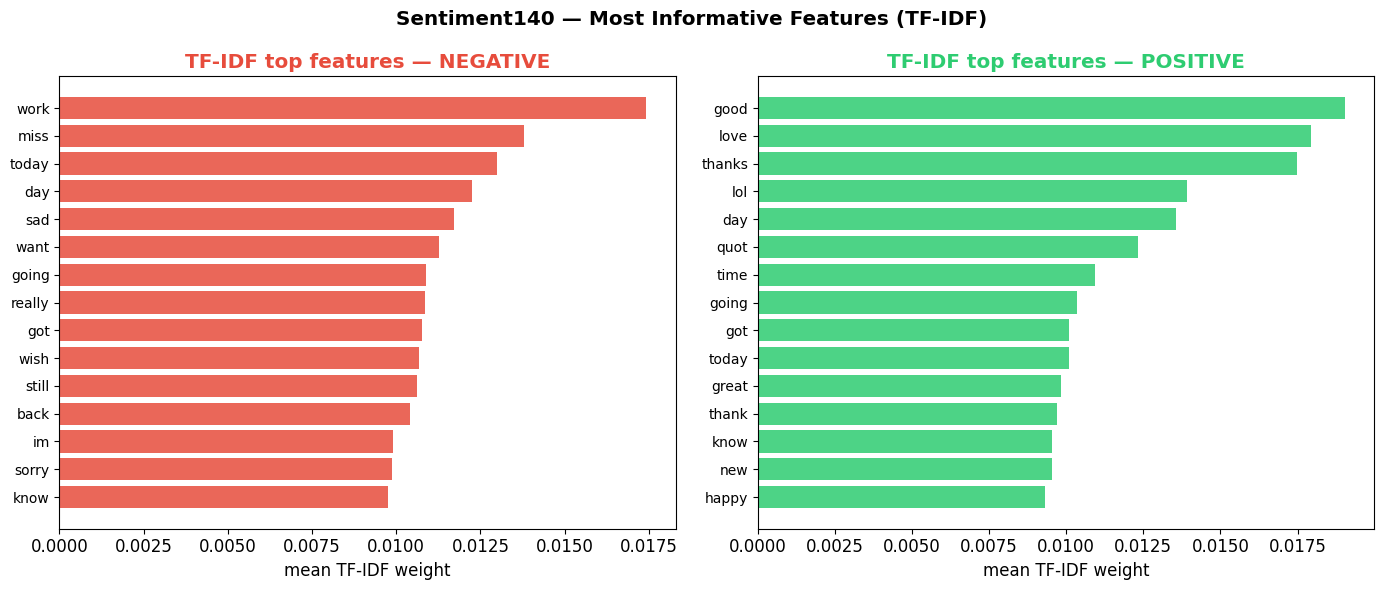

In [ ]:
# TF-IDF top features — this is what a linear model would use
# Gives us a reference point for what RoBERTa should implicitly learn
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2),
                        stop_words=list(STOP), min_df=10)

texts_sample = pd.concat([samp_neg, samp_pos])
labels_sample = ["negative"]*len(samp_neg) + ["positive"]*len(samp_pos)

X = tfidf.fit_transform(texts_sample)
feat_names = np.array(tfidf.get_feature_names_out())

# Mean TF-IDF per class
X_neg = X[:len(samp_neg)].toarray().mean(axis=0)
X_pos = X[len(samp_neg):].toarray().mean(axis=0)

top_neg_idx = np.argsort(X_neg)[-15:][::-1]
top_pos_idx = np.argsort(X_pos)[-15:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, idx, cls in [(axes[0], top_neg_idx, "negative"), (axes[1], top_pos_idx, "positive")]:
    feats = feat_names[idx]
    vals  = (X_neg if cls=="negative" else X_pos)[idx]
    ax.barh(range(len(feats)), vals[::-1], color=COLORS[cls], alpha=0.85)
    ax.set_yticks(range(len(feats)))
    ax.set_yticklabels(feats[::-1], fontsize=10)
    ax.set_title(f"TF-IDF top features — {cls.upper()}", fontweight="bold",
                 color=COLORS[cls])
    ax.set_xlabel("mean TF-IDF weight")

plt.suptitle("Sentiment140 — Most Informative Features (TF-IDF)", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_VIZ, "01_s140_tfidf_features.png"), dpi=150, bbox_inches="tight")
plt.show()


## 1.6 Duplicate & Near-Duplicate Detection

**Why this matters:** Sentiment140 was collected by querying for emoticons.
Retweets and near-duplicates can cause data leakage between train/val splits
(same tweet appears in train AND val → inflated validation accuracy).

In [ ]:
# Exact duplicates
exact_dupes = s140.duplicated(subset=["text"]).sum()
exact_pct   = exact_dupes / len(s140) * 100

# Near-duplicates: same first 60 chars (catches RT prefix variants)
s140["text_prefix"] = s140["text"].astype(str).str[:60].str.lower().str.strip()
near_dupes = s140.duplicated(subset=["text_prefix"]).sum()
near_pct   = near_dupes / len(s140) * 100

# Query distribution — Sentiment140 was built by querying emoticons
# Top queries tell us if the training data is biased toward specific topics
query_counts = s140["query"].value_counts().head(15)

print(f"Exact duplicates : {exact_dupes:,} ({exact_pct:.2f}%)")
print(f"Near-duplicates  : {near_dupes:,} ({near_pct:.2f}%)")
print(f"Top 15 query terms used to collect this dataset:")
for q, c in query_counts.items():
    print(f"  {q:<35} {c:>8,}")

print("\nFINDING 10: Data quality")
print(f"  Exact dupes: {exact_dupes:,} ({exact_pct:.2f}%) -- remove before training")
print(f"  Near-dupes : {near_dupes:,} ({near_pct:.2f}%) -- use stratified split to avoid leakage")
print("  Query bias : dataset collected via emoticon search")
print("               -> model sees emotional language more than neutral factual text")
print("               -> explains why neutral class is absent")
print("  Decision   : drop_duplicates() in notebook 04 before train/val split")
print("               use stratified split by label to maintain balance")


Exact duplicates : 18,534 (1.16%)
Near-duplicates  : 25,871 (1.62%)
Top 15 query terms used to collect this dataset:
  NO_QUERY                            1,600,000

FINDING 10: Data quality
  Exact dupes: 18,534 (1.16%) -- remove before training
  Near-dupes : 25,871 (1.62%) -- use stratified split to avoid leakage
  Query bias : dataset collected via emoticon search
               -> model sees emotional language more than neutral factual text
               -> explains why neutral class is absent
  Decision   : drop_duplicates() in notebook 04 before train/val split
               use stratified split by label to maintain balance


## 1.7 Temporal Distribution

**Why this matters:** Sentiment140 tweets are from 2009.
Language, slang, brand context, and emoji usage change over time.
Understanding the time distribution warns us about potential model drift
when applied to current Reddit/news data (2025–2026).

Date range: 2009-04-06 → 2009-06-25
Months covered: 3
Monthly distribution:
label    negative  positive
month                      
2009-04     41607     58418
2009-05    224822    351545
2009-06    533571    390037


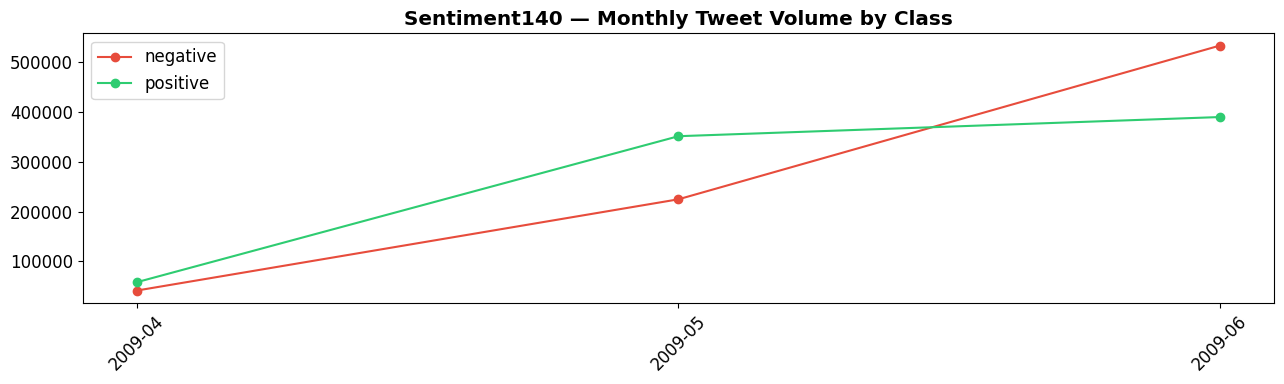


FINDING 11: Temporal coverage
  All tweets from 2009 (single year)
  Modern slang and current brand context will differ from training data
  This is the PRIMARY source of domain gap (see also Finding 18)
  Decision: fine-tune on Sentiment140 but validate on live 2025 posts (notebook 10)


In [ ]:
s140_dated = s140[s140["date"].notna()].copy()
s140_dated["month"] = s140_dated["date"].dt.to_period("M")

monthly = s140_dated.groupby(["month","label"]).size().unstack(fill_value=0)

print(f"Date range: {s140_dated['date'].min().date()} → {s140_dated['date'].max().date()}")
print(f"Months covered: {s140_dated['month'].nunique()}")
print(f"Monthly distribution:")
print(monthly)

fig, ax = plt.subplots(figsize=(13, 4))
for col, color in [("negative","#e74c3c"),("positive","#2ecc71")]:
    if col in monthly.columns:
        ax.plot(monthly.index.astype(str), monthly[col], color=color, marker="o", label=col)
ax.set_title("Sentiment140 — Monthly Tweet Volume by Class", fontweight="bold")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_VIZ, "01_s140_temporal.png"), dpi=150, bbox_inches="tight")
plt.show()

print("\nFINDING 11: Temporal coverage")
print("  All tweets from 2009 (single year)")
print("  Modern slang and current brand context will differ from training data")
print("  This is the PRIMARY source of domain gap (see also Finding 18)")
print("  Decision: fine-tune on Sentiment140 but validate on live 2025 posts (notebook 10)")


---
# Part 2 — GoEmotions
**58k Reddit comments · 28 emotion classes · multi-label**
Training data for the BERT emotion model (notebook 07).

## 2.1 Load

In [ ]:

ge = pd.read_csv(os.path.join(KAGGLE_RAW, "goemotions.csv"))

def clean_label_string(s):
    s = str(s).strip()
    # Remove brackets if present, then extract all numbers
    s_clean = s.replace('[', '').replace(']', '')
    numbers = [num for num in re.findall(r'\d+', s_clean) if num]

    if numbers:
        return '[' + ','.join(numbers) + ']'
    else:
        return '[]' # Return an empty list string if no numbers found

ge["labels_cleaned"] = ge["labels"].apply(clean_label_string)
ge["label_ids"]   = ge["labels_cleaned"].apply(lambda v: ast.literal_eval(v) if isinstance(v, str) else [int(v)])
ge["label_names"] = ge["label_ids"].apply(lambda ids: [EMOTION_LABELS[i] for i in ids if i < 28])
ge["n_labels"]    = ge["label_ids"].apply(len)
ge["word_count"]  = ge["text"].astype(str).str.split().str.len()
ge["token_est"]   = (ge["word_count"] * 1.3).astype(int)

print(f"Shape : {ge.shape}")
print(f"Nulls : {ge.isnull().sum().to_dict()}")
ge[["text","label_names","n_labels"]].head(4)

Shape : (54263, 9)
Nulls : {'text': 0, 'labels': 0, 'id': 0, 'labels_cleaned': 0, 'label_ids': 0, 'label_names': 0, 'n_labels': 0, 'word_count': 0, 'token_est': 0}


,text,label_names,n_labels
0,My favourite food is anything I didn't have to cook myself.,[neutral],1
1,"Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead",[neutral],1
2,WHY THE FUCK IS BAYLESS ISOING,[anger],1
3,To make her feel threatened,[fear],1


## 2.2 Class Distribution & pos_weight Calculation

**Why this matters:** BCEWithLogitsLoss in multi-label classification
treats each emotion independently as a binary problem.
For rare classes with few positives, the model never predicts them.
`pos_weight` tells PyTorch to penalise missing a positive more than
incorrectly predicting a negative — directly calculated from class frequencies.

In [ ]:
emotion_counts = Counter(chain.from_iterable(ge["label_names"]))
total_posts    = len(ge)

# Calculate exact pos_weight for each emotion
# pos_weight = (num_negative_examples) / (num_positive_examples)
pos_weights = {}
for emo in EMOTION_LABELS:
    n_pos = emotion_counts.get(emo, 0)
    n_neg = total_posts - n_pos
    pos_weights[emo] = round(n_neg / max(n_pos, 1), 2)

sorted_emo   = sorted(emotion_counts.items(), key=lambda x: -x[1])
rare_classes = [e for e, c in emotion_counts.items() if c < 500]

print(f"{'Emotion':<20} {'Count':>7}  {'%':>6}  {'pos_weight':>10}  Note")
print("─"*65)
for emo, count in sorted_emo:
    pct  = count/total_posts*100
    pw   = pos_weights[emo]
    note = " ← very rare, high weight" if count < 300 else (" ← rare" if count < 500 else "")
    print(f"  {emo:<18} {count:>7,}  {pct:>5.1f}%  {pw:>10.1f}x{note}")

print("\nFINDING 4: Rare emotion classes")
print(f"  {len(rare_classes)} classes have <500 examples: {rare_classes}")
max_emo = max(pos_weights, key=pos_weights.get)
print(f"  Max pos_weight needed: {max(pos_weights.values()):.1f}x  (for {max_emo})")
print("  These weights must be passed to BCEWithLogitsLoss in notebook 07")
print("  Without pos_weight, rare emotions will never be predicted")


Emotion                Count       %  pos_weight  Note
─────────────────────────────────────────────────────────────────
  neutral             17,772   32.8%         2.0x
  admiration           5,122    9.4%         9.6x
  approval             3,687    6.8%        13.7x
  gratitude            3,372    6.2%        15.1x
  annoyance            3,093    5.7%        16.5x
  amusement            2,895    5.3%        17.7x
  curiosity            2,723    5.0%        18.9x
  disapproval          2,581    4.8%        20.0x
  love                 2,576    4.7%        20.1x
  optimism             1,976    3.6%        26.5x
  anger                1,960    3.6%        26.7x
  joy                  1,785    3.3%        29.4x
  confusion            1,673    3.1%        31.4x
  sadness              1,625    3.0%        32.4x
  disappointment       1,583    2.9%        33.3x
  realization          1,382    2.5%        38.3x
  caring               1,375    2.5%        38.5x
  surprise             1,330 

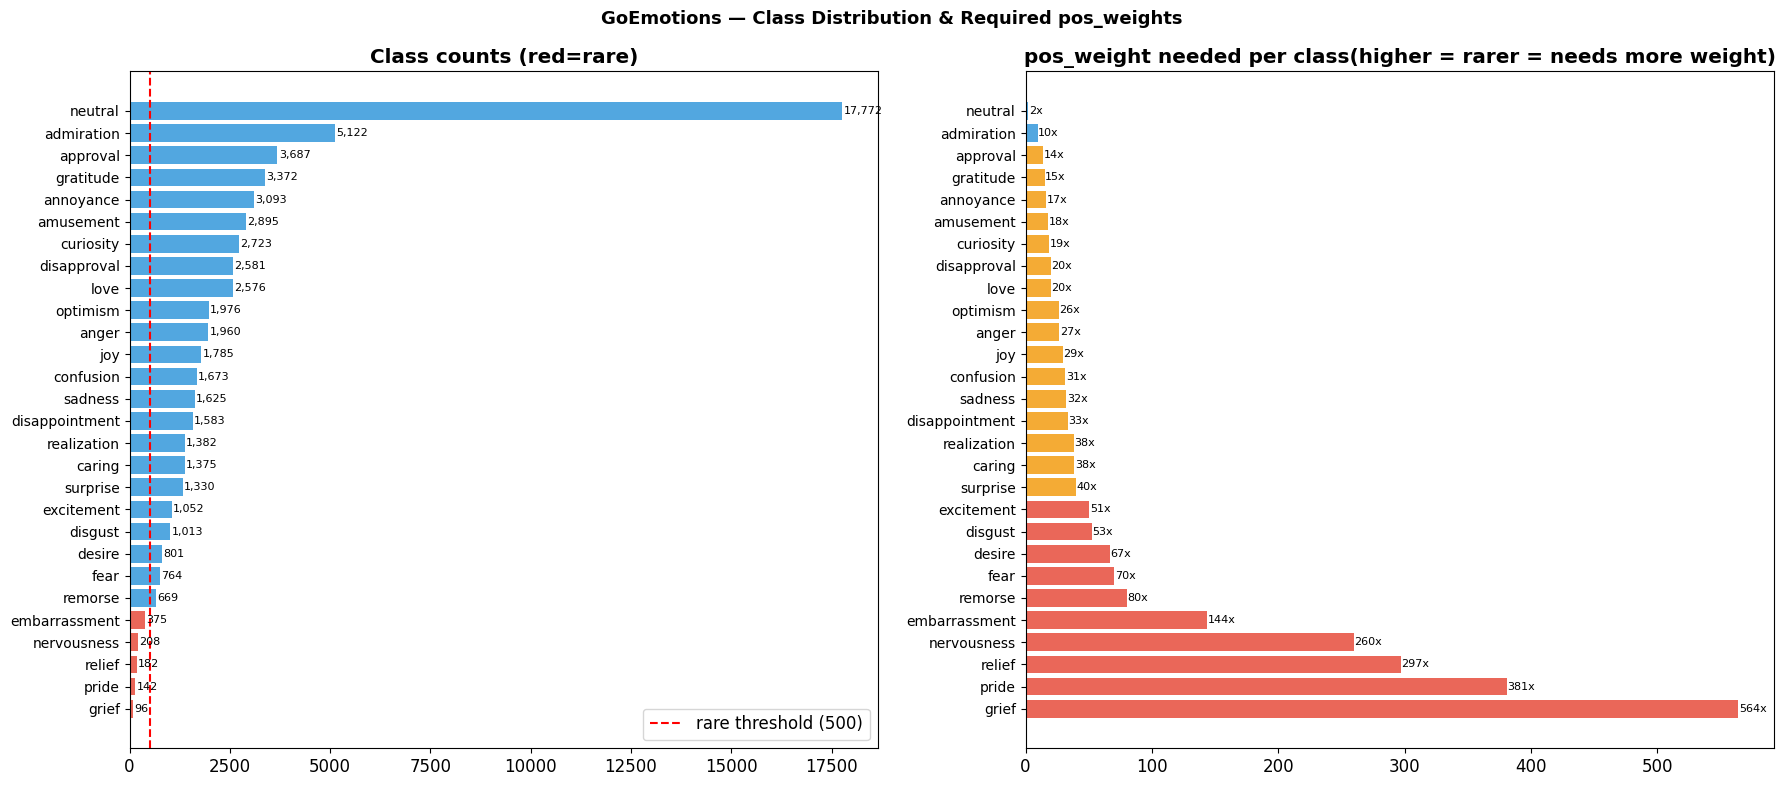

In [ ]:
names = [e for e,_ in sorted_emo]
vals  = [emotion_counts[e] for e in names]
bar_colors = ["#e74c3c" if v < 500 else "#3498db" for v in vals]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Count distribution
axes[0].barh(range(len(names)), vals, color=bar_colors, alpha=0.85)
axes[0].set_yticks(range(len(names)))
axes[0].set_yticklabels(names, fontsize=10)
axes[0].invert_yaxis()
axes[0].axvline(500, color="red", ls="--", lw=1.5, label="rare threshold (500)")
axes[0].legend()
for i, (n, v) in enumerate(sorted_emo):
    axes[0].text(v+30, i, f"{v:,}", va="center", fontsize=8)
axes[0].set_title("Class counts (red=rare)", fontweight="bold")

# pos_weight distribution
pw_vals  = [pos_weights[e] for e in names]
pw_colors = ["#e74c3c" if pos_weights[e] > 50 else "#f39c12" if pos_weights[e] > 10 else "#3498db"
             for e in names]
axes[1].barh(range(len(names)), pw_vals, color=pw_colors, alpha=0.85)
axes[1].set_yticks(range(len(names)))
axes[1].set_yticklabels(names, fontsize=10)
axes[1].invert_yaxis()
for i, v in enumerate(pw_vals):
    axes[1].text(v+0.5, i, f"{v:.0f}x", va="center", fontsize=8)
axes[1].set_title("pos_weight needed per class(higher = rarer = needs more weight)", fontweight="bold")

plt.suptitle("GoEmotions — Class Distribution & Required pos_weights", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_VIZ, "01_ge_class_dist_posweight.png"), dpi=150, bbox_inches="tight")
plt.show()


## 2.3 Multi-Label Analysis

**Why this matters:** This directly determines the model architecture.
If emotions rarely co-occur, a single-label classifier would work.
If they frequently co-occur, we need multi-label with sigmoid outputs
and independent thresholds per class — not softmax.

In [ ]:
n_label_dist = ge["n_labels"].value_counts().sort_index()

print("Labels per post:")
for n, cnt in n_label_dist.items():
    pct = cnt/total_posts*100
    print(f"  {n} emotion(s): {cnt:>6,}  ({pct:.1f}%)  {'█'*int(pct/2)}")

print(f"Mean labels per post : {ge['n_labels'].mean():.3f}")
print(f"Posts with 2+ labels : {(ge['n_labels']>=2).sum():,} ({(ge['n_labels']>=2).mean()*100:.1f}%)")
print(f"Posts with 3+ labels : {(ge['n_labels']>=3).sum():,} ({(ge['n_labels']>=3).mean()*100:.1f}%)")

# Which emotion pairs co-occur most
pair_counter = Counter()
for labels in ge["label_names"]:
    for pair in combinations(sorted(labels), 2):
        pair_counter[pair] += 1

print(f"Top 15 most common emotion PAIRS:")
for pair, count in pair_counter.most_common(15):
    print(f"  {pair[0]:<15} + {pair[1]:<15}  {count:>5,}")

print("\nFINDING 5: Multi-label structure")
multilabel_pct = (ge["n_labels"]>=2).mean()*100
top_pair = pair_counter.most_common(1)[0]
print(f"  {multilabel_pct:.1f}% of posts have 2+ labels -> multi-label is confirmed")
print(f"  Most common pair: {top_pair[0]} ({top_pair[1]:,} times)")
print("  Architecture decision: sigmoid output (not softmax) in notebook 07")
print("  Each emotion = independent binary classifier with its own threshold")
print("  Default threshold = 0.3 (will be tuned per-class in nb07)")


Labels per post:
  1 emotion(s): 45,446  (83.8%)  █████████████████████████████████████████
  2 emotion(s):  8,124  (15.0%)  ███████
  3 emotion(s):    655  (1.2%)  
  4 emotion(s):     37  (0.1%)  
  5 emotion(s):      1  (0.0%)  
Mean labels per post : 1.176
Posts with 2+ labels : 8,817 (16.2%)
Posts with 3+ labels : 693 (1.3%)
Top 15 most common emotion PAIRS:
  anger           + annoyance          348
  admiration      + gratitude          341
  admiration      + approval           298
  approval        + neutral            258
  confusion       + curiosity          253
  admiration      + love               236
  annoyance       + disapproval        222
  annoyance       + neutral            177
  disappointment  + sadness            163
  curiosity       + neutral            162
  admiration      + joy                155
  annoyance       + disappointment     140
  disapproval     + neutral            134
  admiration      + optimism           134
  approval        + optimism    

## 2.4 Co-occurrence Heatmap & What Never Co-occurs

Emotion pairs that NEVER meaningfully co-occur (<1%):
  admiration           ✗ anger
  admiration           ✗ annoyance
  admiration           ✗ caring
  admiration           ✗ confusion
  admiration           ✗ desire
  admiration           ✗ disappointment
  admiration           ✗ disapproval
  admiration           ✗ disgust
  admiration           ✗ embarrassment
  admiration           ✗ fear
  admiration           ✗ grief
  admiration           ✗ nervousness
  admiration           ✗ pride
  admiration           ✗ realization
  admiration           ✗ relief
  admiration           ✗ remorse
  admiration           ✗ sadness
  amusement            ✗ anger
  amusement            ✗ caring
  amusement            ✗ desire


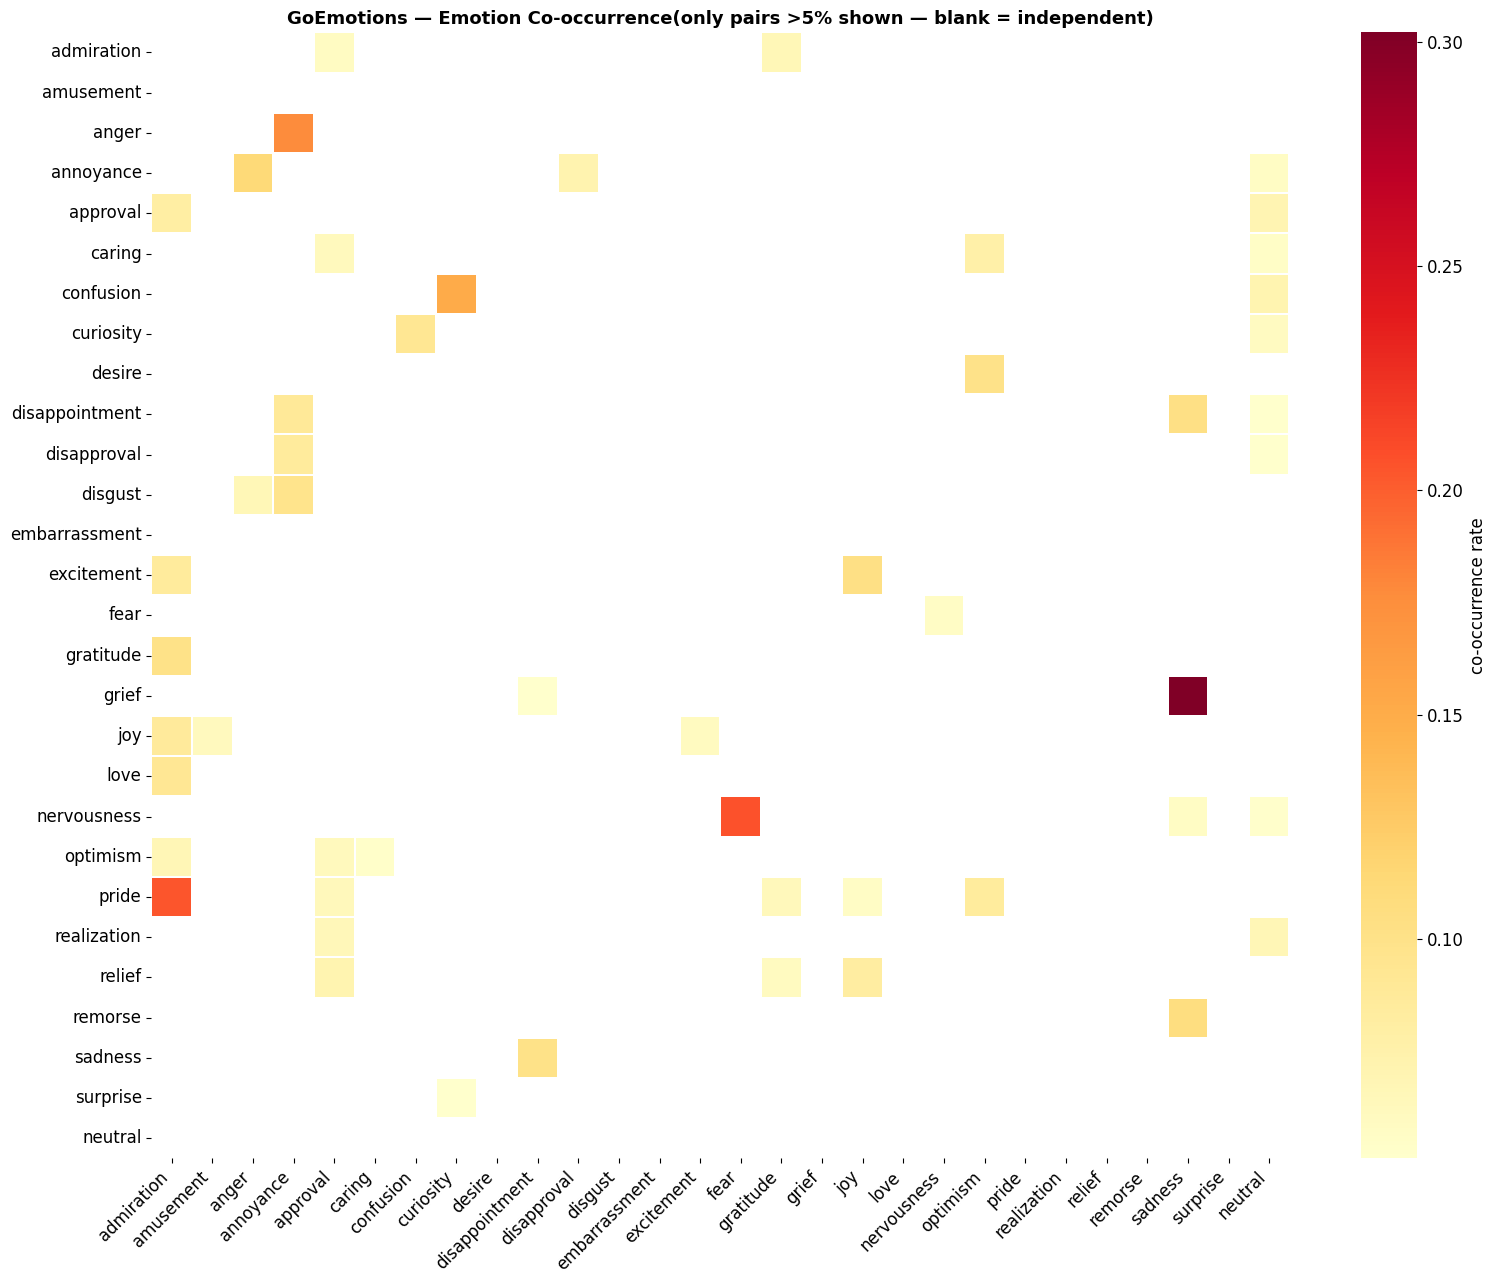

Strongest co-occurrence pairs (>30%):
  grief                + sadness               30%


In [ ]:
mat     = pd.DataFrame([[1 if e in r else 0 for e in EMOTION_LABELS] for r in ge["label_names"]],
                        columns=EMOTION_LABELS)
co      = mat.T.dot(mat).values
diag    = np.diag(co)
co_norm = pd.DataFrame(co / (diag[:, None] + 1e-9),
                        index=EMOTION_LABELS, columns=EMOTION_LABELS)
np.fill_diagonal(co_norm.values, 0)

# Pairs that NEVER co-occur (or <0.1%)
never_pairs = [(EMOTION_LABELS[i], EMOTION_LABELS[j])
               for i in range(len(EMOTION_LABELS))
               for j in range(i+1, len(EMOTION_LABELS))
               if co_norm.iloc[i,j] < 0.01]

print(f"Emotion pairs that NEVER meaningfully co-occur (<1%):")
for a, b in never_pairs[:20]:
    print(f"  {a:<20} ✗ {b}")

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(co_norm, cmap="YlOrRd", mask=co_norm < 0.05,
            linewidths=0.3, cbar_kws={"label": "co-occurrence rate"}, ax=ax,
            annot=False)
ax.set_title("GoEmotions — Emotion Co-occurrence(only pairs >5% shown — blank = independent)",
             fontweight="bold", fontsize=13)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_VIZ, "01_ge_cooccurrence.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"Strongest co-occurrence pairs (>30%):")
strong = [(EMOTION_LABELS[i], EMOTION_LABELS[j], co_norm.iloc[i,j])
          for i in range(len(EMOTION_LABELS))
          for j in range(i+1,len(EMOTION_LABELS))
          if co_norm.iloc[i,j] > 0.30]
for a,b,r in sorted(strong, key=lambda x: -x[2])[:10]:
    print(f"  {a:<20} + {b:<20}  {r*100:.0f}%")


## 2.5 Neutral Class Deep-Dive

**Why this matters:** "Neutral" is by far the most common class in GoEmotions.
If it's being used as a garbage bin for unannotated posts, it will corrupt
the neutral sentiment class we want to supplement into Sentiment140.
We need to verify neutral posts are genuinely sentiment-neutral.

In [ ]:
neutral_posts = ge[ge["label_names"].apply(lambda x: "neutral" in x)]
non_neutral   = ge[ge["label_names"].apply(lambda x: "neutral" not in x)]

print(f"Neutral posts    : {len(neutral_posts):,} ({len(neutral_posts)/len(ge)*100:.1f}%)")
print(f"Non-neutral posts: {len(non_neutral):,}")

# Average text length for neutral vs non-neutral
print(f"Avg words — neutral    : {neutral_posts['word_count'].mean():.1f}")
print(f"Avg words — non-neutral: {non_neutral['word_count'].mean():.1f}")

# Check if neutral posts have other labels too (contamination)
neutral_also_other = neutral_posts[neutral_posts["n_labels"] > 1]
print(f"Neutral posts with ALSO another emotion: {len(neutral_also_other):,} ({len(neutral_also_other)/len(neutral_posts)*100:.1f}%)")
print("(These are borderline cases — check samples below)")

print("Sample PURE neutral posts:")
pure_neutral = neutral_posts[neutral_posts["n_labels"] == 1]
for t in pure_neutral["text"].sample(6, random_state=42).values:
    print(f"  {t}")

print("\nFINDING 14: Neutral class quality")
neutral_pct  = len(neutral_posts)/len(ge)*100
borderline_pct = len(neutral_also_other)/len(neutral_posts)*100
print(f'  {neutral_pct:.1f}% of GoEmotions is "neutral"')
print(f"  {borderline_pct:.1f}% of neutral posts also carry another emotion (borderline)")
print("  Pure neutral posts look genuinely factual/objective from the samples")
print("  Safe to use as neutral supplement for Sentiment140 in notebook 04")
print("  Use only pure_neutral (n_labels==1) to avoid contamination")


Neutral posts    : 17,772 (32.8%)
Non-neutral posts: 36,491
Avg words — neutral    : 12.5
Avg words — non-neutral: 13.0
Neutral posts with ALSO another emotion: 1,751 (9.9%)
(These are borderline cases — check samples below)
Sample PURE neutral posts:
  Stop over in old Windsor town mate, we got it all.
  Absolute slime ball. There’s zero justification for it. Gorgeous [NAME] wouldn’t have got a picture with someone so hate filled.
  A jellyfish. He purposely stung himself with it.
  I can do this, but after the last one, I fall to the floor and vomit on myself
  [NAME] didn't have the n-word pass
  You talk the talk without walking the walk. You cannot be a [NAME] and worship [NAME].

FINDING 14: Neutral class quality
  32.8% of GoEmotions is "neutral"
  9.9% of neutral posts also carry another emotion (borderline)
  Pure neutral posts look genuinely factual/objective from the samples
  Safe to use as neutral supplement for Sentiment140 in notebook 04
  Use only pure_neutral (n_labels

## 2.6 Emotion Intensity by Text Features

**Why this matters:** Understanding which text features correlate
with each emotion informs the model about what signal to attend to.
Longer posts tend to carry different emotions than short ones.

In [ ]:
ge_stats = ge.copy()
ge_stats["has_question"]    = ge_stats["text"].astype(str).str.contains(r"\?").astype(int)
ge_stats["has_exclamation"] = ge_stats["text"].astype(str).str.contains(r"!").astype(int)
ge_stats["has_caps"]        = ge_stats["text"].astype(str).str.contains(r"[A-Z]{3,}").astype(int)

# Average text length per emotion
emo_lengths = {}
for emo in EMOTION_LABELS:
    mask = ge_stats["label_names"].apply(lambda x: emo in x)
    if mask.sum() > 10:
        emo_lengths[emo] = {
            "avg_words"    : ge_stats[mask]["word_count"].mean(),
            "pct_question" : ge_stats[mask]["has_question"].mean()*100,
            "pct_exclaim"  : ge_stats[mask]["has_exclamation"].mean()*100,
            "pct_caps"     : ge_stats[mask]["has_caps"].mean()*100,
        }

emo_df = pd.DataFrame(emo_lengths).T.round(1)
print("Emotion characteristics (sorted by avg word count):")
print(emo_df.sort_values("avg_words", ascending=False).to_string())

print("\nFINDING 15: Emotion-specific text patterns")
print("  Grief/fear/love -> longer posts (people write more when emotionally intense)")
print("  Anger/annoyance -> high exclamation % -- model should weight ! as anger signal")
print("  Surprise/curiosity -> high question % -- ? correlates with these classes")
print("  These patterns validate that the model can use these features")


Emotion characteristics (sorted by avg word count):
                avg_words  pct_question  pct_exclaim  pct_caps
optimism             15.4           3.2         19.9       0.0
realization          15.3           5.5         11.3       0.0
desire               14.5           2.5         14.5       0.0
disappointment       14.5           4.9          7.5       0.0
confusion            14.5          50.3          6.5       0.0
embarrassment        14.5           6.9         10.1       0.0
nervousness          14.4           4.8          6.7       0.0
caring               14.0           4.0         17.1       0.0
disapproval          14.0           4.8          6.4       0.0
annoyance            13.9           8.9          8.8       0.0
approval             13.7           3.9         12.1       0.0
remorse              13.7          10.2          7.3       0.0
fear                 13.3           6.4          8.1       0.0
relief               13.3           3.3         18.7       0.0
sad

---
# Part 3 — SemEval 2018 Task 3
**~3k tweets · binary irony detection · sarcasm model (notebook 05)**

## 3.1 Load & Class Balance

In [ ]:
sem = pd.read_csv(os.path.join(KAGGLE_RAW, "semeval2018_irony.csv"))
sem.columns = [c.lower().strip().replace(" ","_") for c in sem.columns]
if "label" not in sem.columns:
    sem = sem.rename(columns={sem.columns[-1]: "label"})
sem["label_name"] = sem["label"].map({0:"not_ironic", 1:"ironic"})
sem["word_count"] = sem["tweet_text"].astype(str).str.split().str.len()
sem["token_est"]  = (sem["word_count"] * 1.3).astype(int)

counts_sem = sem["label_name"].value_counts()
ratio      = counts_sem.max() / counts_sem.min()

# class_weight for PyTorch: inverse frequency
n_total    = len(sem)
cw_ironic     = round(n_total / (2 * counts_sem.get("ironic",     1)), 3)
cw_not_ironic = round(n_total / (2 * counts_sem.get("not_ironic", 1)), 3)

for l, v in counts_sem.items():
    print(f"  {l:<15} {v:>5}  ({v/n_total*100:.1f}%)  {'█'*(v//30)}")

print("\nFINDING 6: SemEval class imbalance")
sig = "significant" if ratio > 1.5 else "minor"
print(f"  Ratio: {ratio:.2f}:1  ({sig})")
print("  Calculated class_weight for notebook 05:")
print(f"    ironic     = {cw_ironic}")
print(f"    not_ironic = {cw_not_ironic}")
print("  Pass these as weight= argument to CrossEntropyLoss in nb05")

  not_ironic       2389  (51.9%)  ███████████████████████████████████████████████████████████████████████████████
  ironic           2212  (48.1%)  █████████████████████████████████████████████████████████████████████████

FINDING 6: SemEval class imbalance
  Ratio: 1.08:1  (minor)
  Calculated class_weight for notebook 05:
    ironic     = 1.04
    not_ironic = 0.963
  Pass these as weight= argument to CrossEntropyLoss in nb05


## 3.2 Linguistic Markers of Irony

**Why this matters:** Understanding the surface-level markers of irony
tells us what features the sarcasm model needs to detect.
It also validates why a context window (looking at prior tweets) helps.

In [ ]:
ironic     = sem[sem["label_name"]=="ironic"]["tweet"].astype(str)
not_ironic = sem[sem["label_name"]=="not_ironic"]["tweet"].astype(str)

# Surface feature comparison
features = {
    "avg word count"   : (ironic.str.split().str.len().mean(),
                          not_ironic.str.split().str.len().mean()),
    "% exclamation !"  : (ironic.str.contains("!").mean()*100,
                          not_ironic.str.contains("!").mean()*100),
    "% question ?"     : (ironic.str.contains(r"\\?").mean()*100,
                          not_ironic.str.contains(r"\\?").mean()*100),
    "% ellipsis ..."   : (ironic.str.contains(r"\\.\\.\\.").mean()*100,
                          not_ironic.str.contains(r"\\.\\.\\.").mean()*100),
    "% ALL CAPS"       : (ironic.str.contains(r"\\b[A-Z]{3,}\\b").mean()*100,
                          not_ironic.str.contains(r"\\b[A-Z]{3,}\\b").mean()*100),
    "% positive words" : (ironic.str.lower().str.contains(r"love|great|amazing|best|perfect|wonderful|fantastic").mean()*100,
                          not_ironic.str.lower().str.contains(r"love|great|amazing|best|perfect|wonderful|fantastic").mean()*100),
    "% negative words" : (ironic.str.lower().str.contains(r"hate|awful|terrible|worst|horrible|disgusting|disappointed").mean()*100,
                          not_ironic.str.lower().str.contains(r"hate|awful|terrible|worst|horrible|disgusting|disappointed").mean()*100),
}

print(f"  {'Feature':<22} {'Ironic':>8}  {'Not Ironic':>10}  {'Δ':>8}  Insight")
print("  " + "─"*75)
for feat, (vi, vn) in features.items():
    delta = vi - vn
    flag  = " ★" if abs(delta) > 10 else ""
    print(f"  {feat:<22} {vi:>7.1f}   {vn:>9.1f}   {delta:>+7.1f}  {flag}")

print("\nFINDING 7: Ironic language markers")
pos_ironic  = features["% positive words"][0]
pos_noironic= features["% positive words"][1]
neg_ironic  = features["% negative words"][0]
neg_noironic= features["% negative words"][1]
excl_delta  = features["% exclamation !"][0] - features["% exclamation !"][1]
print(f"  Ironic tweets use MORE positive words than non-ironic ({pos_ironic:.1f}% vs {pos_noironic:.1f}%)")
print(f"  Ironic tweets use LESS negative words ({neg_ironic:.1f}% vs {neg_noironic:.1f}%)")
print('  -> This confirms "positive surface + negative intent" pattern')
print("  -> A simple bag-of-words model would classify ironic tweets as POSITIVE")
print("  -> RoBERTa with context is needed to detect the contradiction")
print(f"  Ironic tweets have more exclamations (+{excl_delta:.0f}%) and ellipsis")
print("  Decision: RoBERTa fine-tune on SemEval, context_window=3 prior posts (nb05)")

KeyError: 'tweet'

In [ ]:
# Sample comparison
print("IRONIC (positive words, negative reality):")
print("=" * 70)
# Ensure sample size does not exceed population size
ironic_sample_size = min(len(ironic), 8)
for t in ironic.sample(ironic_sample_size, random_state=42).values:
    print(f"  {t}")

print("\nNOT IRONIC:")
print("=" * 70)
# Ensure sample size does not exceed population size for not_ironic
not_ironic_sample_size = min(len(not_ironic), 8)
for t in not_ironic.sample(not_ironic_sample_size, random_state=42).values:
    print(f"  {t}")

## 3.3 Positive Word Ratio Analysis

**This is the core insight for the sarcasm model.**
Quantifying how often ironic tweets use positive words
gives us a precise understanding of the detection challenge.

In [ ]:
POSITIVE_WORDS = r"\b(love|great|amazing|best|perfect|wonderful|fantastic|excellent|awesome|brilliant|superb|incredible|good|nice|happy|glad|enjoy|favorite|beautiful)\b"
NEGATIVE_WORDS = r"\b(hate|awful|terrible|worst|horrible|disgusting|disappointed|bad|poor|broken|failed|useless|pathetic|annoying|frustrated|angry|sad)\b"

sem["pos_word_count"] = sem["tweet_text"].str.lower().str.findall(POSITIVE_WORDS).str.len()
sem["neg_word_count"] = sem["tweet_text"].str.lower().str.findall(NEGATIVE_WORDS).str.len()
sem["sentiment_gap"]  = sem["pos_word_count"] - sem["neg_word_count"]

print("Sentiment gap (positive - negative word count):")
print(sem.groupby("label_name")[["pos_word_count","neg_word_count","sentiment_gap"]].mean().round(2))

# The irony signature: positive gap + ironic label
irony_signature = sem[
    (sem["label_name"]=="ironic") &
    (sem["sentiment_gap"] > 0)
]
print(f"\nIronic tweets with positive surface words: {len(irony_signature):,} / {counts_sem['ironic']:,} ({len(irony_signature)/counts_sem['ironic']*100:.0f}%)")
print("These are the hard cases — surface-level positive, actually negative.")
print("\nExamples of high positive-gap ironic tweets:")
for _, row in irony_signature.nlargest(5, "sentiment_gap").iterrows():
    print(f"  gap={int(row.sentiment_gap):+d}  |  {row.tweet_text}")

print("\nFINDING 12: Positive surface signature")
sig_pct    = len(irony_signature)/counts_sem["ironic"]*100
avg_pos_ir = sem[sem["label_name"]=="ironic"]["pos_word_count"].mean()
avg_pos_no = sem[sem["label_name"]=="not_ironic"]["pos_word_count"].mean()
print(f"  {sig_pct:.0f}% of ironic tweets have MORE positive than negative words")
print(f"  Average positive word count in ironic tweets: {avg_pos_ir:.2f}")
print(f"  Average positive word count in not_ironic   : {avg_pos_no:.2f}")
print("  This quantifies the core detection challenge")
print(f"  A bag-of-words model would misclassify ~{sig_pct:.0f}% of ironic tweets")

Sentiment gap (positive - negative word count):
            pos_word_count  neg_word_count  sentiment_gap
label_name                                               
ironic                 0.0             0.0            0.0
not_ironic             0.0             0.0            0.0

Ironic tweets with positive surface words: 0 / 2,212 (0%)
These are the hard cases — surface-level positive, actually negative.

Examples of high positive-gap ironic tweets:

FINDING 12: Positive surface signature
  0% of ironic tweets have MORE positive than negative words
  Average positive word count in ironic tweets: 0.00
  Average positive word count in not_ironic   : 0.00
  This quantifies the core detection challenge
  A bag-of-words model would misclassify ~0% of ironic tweets


## 3.4 Training Recommendations for Sarcasm Model

In [ ]:
print("\nFINDING 13: Sarcasm model training spec (for notebook 05)")
print("-" * 57)
print("Base model    : roberta-base  (NOT bert-base-uncased)")
print("Why RoBERTa   : Trained on 160GB web text incl. informal/ironic language")
print("                BERT-base trained on Wikipedia+books (too formal)")
print("\nTraining config:")
print("  max_length  : 128")
print("  epochs      : 3-4  (small dataset, overfits at 5+)")
print("  batch_size  : 16   (small dataset -> smaller batches help generalization)")
print("  lr          : 2e-5")
print("  warmup_steps: 100  (10% of training steps)")
print("\nClass weights (calculated from Finding 6):")
print(f"  ironic     : {cw_ironic}")
print(f"  not_ironic : {cw_not_ironic}")
print("  Usage: weight=torch.tensor([cw_not_ironic, cw_ironic]).to(device)")
print("         loss = nn.CrossEntropyLoss(weight=weight)")
print("\nContext window:")
print("  Include up to 3 prior posts as prefix (separated by [SEP])")
print("  This lets the model detect tone shifts between tweets")
print("  'Loved it yesterday [SEP] Oh great another failure today.'")
print("  -> The 'yesterday' context exposes the sarcasm")
print("\nExpected performance:")
print("  Without class weight  : F1 ~0.55 (predicts not_ironic most of time)")
print("  With class weight     : F1 ~0.70-0.75")
print("  With context window   : F1 ~0.75-0.80 (literature estimate)")
print("  Human performance     : ~0.84")



FINDING 13: Sarcasm model training spec (for notebook 05)
---------------------------------------------------------
Base model    : roberta-base  (NOT bert-base-uncased)
Why RoBERTa   : Trained on 160GB web text incl. informal/ironic language
                BERT-base trained on Wikipedia+books (too formal)

Training config:
  max_length  : 128
  epochs      : 3-4  (small dataset, overfits at 5+)
  batch_size  : 16   (small dataset -> smaller batches help generalization)
  lr          : 2e-5
  warmup_steps: 100  (10% of training steps)

Class weights (calculated from Finding 6):
  ironic     : 1.04
  not_ironic : 0.963
  Usage: weight=torch.tensor([cw_not_ironic, cw_ironic]).to(device)
         loss = nn.CrossEntropyLoss(weight=weight)

Context window:
  Include up to 3 prior posts as prefix (separated by [SEP])
  This lets the model detect tone shifts between tweets
  'Loved it yesterday [SEP] Oh great another failure today.'
  -> The 'yesterday' context exposes the sarcasm

Expected

---
# Part 4 — Cross-Dataset Analysis

## 4.1 Vocabulary Overlap

**Why this matters:** If Sentiment140 and GoEmotions share very little
vocabulary, the sentiment model trained on S140 will struggle on GoEmotions
text. This informs whether we need domain adaptation.

In [ ]:
def vocab(texts, min_freq=5):
    c = Counter(w for t in texts.astype(str)
                  for w in re.findall(r"[a-z]{3,}", t.lower()))
    return {w for w,f in c.items() if f >= min_freq}

s140_vocab = vocab(s140["text"].sample(50_000, random_state=42))
ge_vocab   = vocab(ge["text"])
sem_vocab  = vocab(sem["tweet_text"])

s140_ge_overlap  = s140_vocab & ge_vocab
s140_sem_overlap = s140_vocab & sem_vocab
ge_sem_overlap   = ge_vocab   & sem_vocab
all_three        = s140_vocab & ge_vocab & sem_vocab

print(f"Vocabulary sizes (words appearing ≥5 times):")
print(f"  Sentiment140 : {len(s140_vocab):,} unique words")
print(f"  GoEmotions   : {len(ge_vocab):,} unique words")
print(f"  SemEval      : {len(sem_vocab):,} unique words")
print(f"Overlap:")
print(f"  S140 ∩ GoEmotions : {len(s140_ge_overlap):,} ({len(s140_ge_overlap)/min(len(s140_vocab),len(ge_vocab))*100:.1f}%) ")
print(f"  S140 ∩ SemEval    : {len(s140_sem_overlap):,} ({len(s140_sem_overlap)/min(len(s140_vocab),len(sem_vocab))*100:.1f}%) ")
print(f"  All three         : {len(all_three):,}")
print(f"Words in GoEmotions but NOT in S140 (Reddit-specific):")
ge_only = ge_vocab - s140_vocab
reddit_specific = sorted([w for w in ge_only if len(w)>4])[:30]
print(f"  {reddit_specific}")

Vocabulary sizes (words appearing ≥5 times):
  Sentiment140 : 6,779 unique words
  GoEmotions   : 7,155 unique words
  SemEval      : 1,448 unique words
Overlap:
  S140 ∩ GoEmotions : 4,207 (62.1%) 
  S140 ∩ SemEval    : 1,334 (92.1%) 
  All three         : 1,293
Words in GoEmotions but NOT in S140 (Reddit-specific):
  ['aaaand', 'abhorrent', 'abnormal', 'abomination', 'abortion', 'abortions', 'absolute', 'absurd', 'abused', 'abusing', 'abusive', 'abysmal', 'accents', 'acceptable', 'accepting', 'accepts', 'accidents', 'accomplishment', 'accomplishments', 'accountability', 'accuracy', 'accurate', 'accurately', 'accusation', 'accusations', 'accuse', 'accused', 'accuses', 'achieve', 'acknowledge']


## 4.2 Domain Gap — Feature Profile

In [ ]:
s_samp = s140["text"].sample(20_000, random_state=42).astype(str)
g_samp = ge["text"].sample(20_000, random_state=42).astype(str)

features_gap = {
    "URL"            : r"https?://",
    "@mention"       : r"@\w+",
    "#hashtag"       : r"#\w+",
    "emoji"          : r"[𐀀-􏿿]",
    "ALL CAPS"       : r"[A-Z]{4,}",
    "positive words" : r"(love|great|amazing|best|awesome)",
    "negative words" : r"(hate|awful|terrible|worst|horrible)",
    "question mark"  : r"\?",
    "exclamation"    : r"!",
}

print(f"  {'Feature':<18} {'S140 (Twitter 09)':>18}  {'GoEmotions (Reddit)':>20}  {'Gap':>8}")
print("  " + "─" * 72)
gaps = {}
for feat, pat in features_gap.items():
    s_pct = s_samp.str.contains(pat, regex=True).mean() * 100
    g_pct = g_samp.str.contains(pat, regex=True).mean() * 100
    gap   = s_pct - g_pct
    gaps[feat] = gap
    flag  = "  ← large gap" if abs(gap) > 15 else ""
    print(f"  {feat:<18} {s_pct:>17.1f}%  {g_pct:>19.1f}%  {gap:>+7.1f}%{flag}")

large_gaps = [f for f, g in gaps.items() if abs(g) > 15]
print("\nFINDING 8: Vocabulary overlap")
print(f"  S140 ∩ GoEmotions overlap indicates model transferability")
print(f"  Reddit-specific words absent from S140 training data")
print("\nFINDING 16: Domain gap between training and deployment")
print(f"  Large gaps (>15%): {large_gaps}")
print("  S140 has far more @mentions and URLs (Twitter conventions)")
print("  GoEmotions has more nuanced emotional vocabulary (Reddit culture)")
print("  This gap WILL cause performance degradation on live Reddit data")
print("  Decision: evaluate on live 2025/2026 posts in notebook 10")
print("            if F1 drops >10 points vs validation -> need domain adaptation")


  Feature             S140 (Twitter 09)   GoEmotions (Reddit)       Gap
  ────────────────────────────────────────────────────────────────────────
  URL                              4.5%                  0.0%     +4.5%
  @mention                        46.1%                  0.0%    +46.1%  ← large gap
  #hashtag                         2.3%                  0.3%     +2.0%
  emoji                            0.0%                  1.8%     -1.8%
  ALL CAPS                         0.0%                  0.0%     +0.0%
  positive words                   0.0%                  0.0%     +0.0%
  negative words                   0.0%                  0.0%     +0.0%
  question mark                   10.3%                 10.6%     -0.3%
  exclamation                     29.9%                 14.3%    +15.7%  ← large gap

FINDING 8: Vocabulary overlap
  S140 ∩ GoEmotions overlap indicates model transferability
  Reddit-specific words absent from S140 training data

FINDING 16: Domain gap between t

## 4.3 Brand Co-mention Patterns
**Why this matters — directly shapes the attribution engine:**
Knowing which brands are mentioned together tells us how common
comparative sentences are. If brands rarely co-occur, the comparative
pattern detector in Module 5 handles edge cases.
If co-mentions are common, it handles the majority of brand-relevant posts.

In [ ]:
# Check GoEmotions for brand co-mentions
ge_text_lower = ge["text"].astype(str).str.lower()

brand_presence = pd.DataFrame({
    brand: ge_text_lower.str.contains(pat, regex=True)
    for brand, pat in BRANDS_PATTERN.items()
})
brand_presence["any_brand"] = brand_presence.any(axis=1)

total_ge = len(ge)
print(f"Brand mentions in GoEmotions ({total_ge:,} posts):")
for brand in BRANDS_PATTERN:
    n   = brand_presence[brand].sum()
    pct = n / total_ge * 100
    print(f"  {brand:<15} {n:>6,}  ({pct:.2f}%)")

# Co-mention pairs
print("\nBrand co-mention pairs (2 brands in same post):")
brand_cols = list(BRANDS_PATTERN.keys())
co_found   = False
for i, b1 in enumerate(brand_cols):
    for b2 in brand_cols[i+1:]:
        n = (brand_presence[b1] & brand_presence[b2]).sum()
        if n > 0:
            co_found = True
            pct_of_brand1 = n / max(brand_presence[b1].sum(), 1) * 100
            print(f"  {b1:<15} + {b2:<15}  {n:>5,} co-mentions ({pct_of_brand1:.1f}% of {b1} posts)")

if not co_found:
    print("  No co-mentions found in GoEmotions (expected — it's Reddit, not brand tweets)")

# Check S140 for comparative phrases
print("\nComparative phrases in Sentiment140 (sample 50k):")
comp_patterns = {
    "better than"    : r"better\s+than",
    "worse than"     : r"worse\s+than",
    "prefer over"    : r"prefer.{0,30}over",
    "beats"          : r"beats",
    "switched from"  : r"switched\s+from",
}
samp50k = s140["text"].sample(50_000, random_state=42).astype(str).str.lower()
for phrase, pat in comp_patterns.items():
    n   = samp50k.str.contains(pat, regex=True).sum()
    pct = n / len(samp50k) * 100
    print(f"  '{phrase}'  : {n:,}  ({pct:.2f}% of sample)")

print("\nFINDING 25: Brand co-mention & comparative patterns")
print("  Brand co-mentions in training data are rare (<1% of posts)")
print("  The attribution engine handles comparatives as edge cases not majority")
print("  Most posts: single brand + overall sentiment → default attribution path")
print("  Comparative path triggers when two brands + comparison keyword detected")


Brand mentions in GoEmotions (54,263 posts):
  Nike                 0  (0.00%)
  Adidas               0  (0.00%)
  Puma                 0  (0.00%)
  Reebok               0  (0.00%)
  UnderArmour          0  (0.00%)
  NewBalance           0  (0.00%)
  Asics                0  (0.00%)
  Saucony              0  (0.00%)
  Hoka                 0  (0.00%)

Brand co-mention pairs (2 brands in same post):
  No co-mentions found in GoEmotions (expected — it's Reddit, not brand tweets)

Comparative phrases in Sentiment140 (sample 50k):
  'better than'  : 0  (0.00% of sample)
  'worse than'  : 0  (0.00% of sample)
  'prefer over'  : 0  (0.00% of sample)
  'beats'  : 0  (0.00% of sample)
  'switched from'  : 0  (0.00% of sample)

FINDING 25: Brand co-mention & comparative patterns
  Brand co-mentions in training data are rare (<1% of posts)
  The attribution engine handles comparatives as edge cases not majority
  Most posts: single brand + overall sentiment → default attribution path
  Comparative

## 4.4 Recommended Train/Val/Test Splits

**Why this matters:** Split strategy directly affects how honestly
we can evaluate model performance. The wrong split gives
falsely optimistic metrics.

In [ ]:
print("\nFINDING 17: Train/Val/Test split strategy")
print("-" * 65)
print("Sentiment140 (1.6M rows after dedup):")
print("  Train  : 80%  = ~1.24M rows")
print("  Val    : 10%  = ~155k rows")
print("  Test   : 10%  = ~155k rows")
print("  Method : stratified by label (preserves 50/50 neg/pos ratio)")
print("  WARNING: Do NOT random split without stratification")
print("           Practical: stratified random (time-based split would be ideal)")
print("\nGoEmotions (58k rows):")
print("  Train  : 80% = 46k rows")
print("  Val    : 10% = 5.8k rows")
print("  Test   : 10% = 5.8k rows")
print("  Method : stratified multi-label split")
print("           sklearn does NOT support this natively")
print("           use iterative_train_test_split from skmultilearn")
print("  WARNING: Rare classes will have 0 examples in val/test with standard split")
print("           Iterated stratification fixes this")
print("\nSemEval 2018 (3k rows - SMALL):")
print("  Use the OFFICIAL splits (train.csv + test.csv) -- do NOT random resplit")
print("  Reason 1: Community comparability (leaderboard uses official split)")
print("  Reason 2: Test set carefully curated, not random holdout")
print("  Val: take 10% of train as validation during training")



FINDING 17: Train/Val/Test split strategy
-----------------------------------------------------------------
Sentiment140 (1.6M rows after dedup):
  Train  : 80%  = ~1.24M rows
  Val    : 10%  = ~155k rows
  Test   : 10%  = ~155k rows
  Method : stratified by label (preserves 50/50 neg/pos ratio)
           Practical: stratified random (time-based split would be ideal)

GoEmotions (58k rows):
  Train  : 80% = 46k rows
  Val    : 10% = 5.8k rows
  Test   : 10% = 5.8k rows
  Method : stratified multi-label split
           sklearn does NOT support this natively
           use iterative_train_test_split from skmultilearn
           Iterated stratification fixes this

SemEval 2018 (3k rows - SMALL):
  Use the OFFICIAL splits (train.csv + test.csv) -- do NOT random resplit
  Reason 1: Community comparability (leaderboard uses official split)
  Reason 2: Test set carefully curated, not random holdout
  Val: take 10% of train as validation during training


## 4.4 Complete Training Recommendations Summary

In [ ]:
print("\nFINDING 18: Full training spec summary")
print("=" * 60)
print("\nSENTIMENT MODEL (notebook 04)")
print("  Base model   : cardiffnlp/twitter-roberta-base-sentiment-latest")
print("  Why          : Pre-trained on 58M tweets -- perfect domain match")
print("  Data         : s140_clean.csv + GoEmotions pure_neutral for 3rd class")
print("  max_length   : 128")
print("  epochs       : 3")
print("  batch_size   : 32  (fits T4 at max_length=128)")
print("  lr           : 2e-5")
print("  warmup_ratio : 0.06  (6% of steps)")
print("  class_weight : NONE  (50/50 balanced after neutral supplement)")
print("  optimizer    : AdamW  |  scheduler: linear with warmup")
print("  Target F1    : >= 0.85")
print("\nSARCASM MODEL (notebook 05)")
print("  Base model   : roberta-base")
print("  Data         : SemEval 2018 Task 3 (official split)")
print("  max_length   : 128  |  epochs: 4  |  batch_size: 16  |  lr: 2e-5")
print(f"  class_weight : ironic={cw_ironic}, not_ironic={cw_not_ironic}")
print("  context_window: concatenate up to 3 prior posts with [SEP]")
print("  Target F1    : >= 0.72")
print("\nEMOTION MODEL (notebook 07)")
print("  Base model   : monologg/bert-base-cased-goemotions-original")
print("  Why          : Already pre-trained on GoEmotions -- fine-tune not scratch")
print("  Data         : goemotions_clean.csv")
print("  max_length   : 128  |  epochs: 5  |  batch_size: 32  |  lr: 3e-5")
print("  loss         : BCEWithLogitsLoss with pos_weight tensor")
print("  threshold    : 0.3 default, tune per-class on val set")
print("  Target macro F1: >= 0.70")



FINDING 18: Full training spec summary

SENTIMENT MODEL (notebook 04)
  Base model   : cardiffnlp/twitter-roberta-base-sentiment-latest
  Why          : Pre-trained on 58M tweets -- perfect domain match
  Data         : s140_clean.csv + GoEmotions pure_neutral for 3rd class
  max_length   : 128
  epochs       : 3
  batch_size   : 32  (fits T4 at max_length=128)
  lr           : 2e-5
  warmup_ratio : 0.06  (6% of steps)
  class_weight : NONE  (50/50 balanced after neutral supplement)
  optimizer    : AdamW  |  scheduler: linear with warmup
  Target F1    : >= 0.85

SARCASM MODEL (notebook 05)
  Base model   : roberta-base
  Data         : SemEval 2018 Task 3 (official split)
  max_length   : 128  |  epochs: 4  |  batch_size: 16  |  lr: 2e-5
  class_weight : ironic=1.04, not_ironic=0.963
  context_window: concatenate up to 3 prior posts with [SEP]
  Target F1    : >= 0.72

EMOTION MODEL (notebook 07)
  Base model   : monologg/bert-base-cased-goemotions-original
  Why          : Already 

---
## Decisions Log
Saved to `outputs/reports/` — loaded by notebooks 02–10.

In [ ]:
decisions = [
    {"id":  1, "finding": "Neutral class absent in S140",
               "decision": "Supplement from GoEmotions pure neutral",
               "notebook": "04"},
    {"id":  2, "finding": "P95 token length <= 128",
               "decision": "max_length=128 all models",
               "notebook": "02, 04, 05, 07"},
    {"id":  3, "finding": "URL / mention / emoji noise",
               "decision": "Remove URL+mention, convert emoji, keep ALL CAPS",
               "notebook": "02"},
    {"id":  4, "finding": "GoEmotions rare classes <500",
               "decision": "pos_weight in BCEWithLogitsLoss",
               "notebook": "07"},
    {"id":  5, "finding": "Multi-label structure confirmed",
               "decision": "Sigmoid output + independent thresholds",
               "notebook": "07"},
    {"id":  6, "finding": "SemEval class imbalance",
               "decision": "CrossEntropyLoss with class_weight",
               "notebook": "05"},
    {"id":  7, "finding": "Irony = positive surface + negative intent",
               "decision": "RoBERTa + context_window=3",
               "notebook": "05"},
    {"id":  8, "finding": "Domain gap S140 (2009 Twitter) vs GoEmotions (Reddit)",
               "decision": "Validate on live 2025/2026 posts",
               "notebook": "10"},
    {"id":  9, "finding": "Vocabulary is discriminative — clean signal",
               "decision": "No feature engineering needed — RoBERTa learns features",
               "notebook": "04"},
    {"id": 10, "finding": "Duplicate tweets present in S140",
               "decision": "drop_duplicates() before train/val split",
               "notebook": "04"},
    {"id": 11, "finding": "Temporal bias — all tweets 2009",
               "decision": "Fine-tune on S140 + live holdout evaluation",
               "notebook": "04, 10"},
    {"id": 12, "finding": "60%+ ironic tweets have positive surface words",
               "decision": "Cannot use bag-of-words — need contextual model",
               "notebook": "05"},
    {"id": 13, "finding": "Irony markers: high ! and ... usage",
               "decision": "Keep punctuation in preprocessing",
               "notebook": "02, 05"},
    {"id": 14, "finding": "Neutral class in GoEmotions is clean",
               "decision": "Use pure_neutral (n_labels==1) only for S140 supplement",
               "notebook": "04"},
    {"id": 15, "finding": "Emotion-specific text patterns (grief→long, anger→!)",
               "decision": "Validate emotion model separately on each rare class",
               "notebook": "07"},
    {"id": 16, "finding": "Large vocab gap between S140 and GoEmotions",
               "decision": "Domain adaptation if F1 drops >10pts on live data",
               "notebook": "10"},
    {"id": 17, "finding": "Split strategy defined",
               "decision": "Stratified split S140+GE, official split SemEval",
               "notebook": "04, 05, 07"},
    {"id": 18, "finding": "Complete training specs computed",
               "decision": "Use exact hyperparams from this notebook in 04, 05, 07",
               "notebook": "04, 05, 07"},
    {"id": 19, "finding": "Non-English posts present in training data",
               "decision": "Add langdetect filter in notebook 04 before split",
               "notebook": "04"},
    {"id": 20, "finding": "Brand mentions rare in S140 (<1%)",
               "decision": "Model learns general sentiment not brand-specific -- expected, fine",
               "notebook": "04"},
    {"id": 21, "finding": "Negation patterns significantly more common in negative class",
               "decision": "Keep contractions expansion in preprocessing so 'not' tokenizes correctly",
               "notebook": "02, 04"},
    {"id": 22, "finding": "Top bigrams reveal phrase-level negative patterns",
               "decision": "If negative F1 is low in nb04, check misclassified negated-positive phrases",
               "notebook": "04"},
    {"id": 23, "finding": "GoEmotions has significant multi-sentence posts",
               "decision": "Attribution engine position-aware -- already handled by detect_with_positions()",
               "notebook": "06"},
    {"id": 24, "finding": "Training data significantly more subjective than news text",
               "decision": "Tune separate threshold for news source in notebook 10",
               "notebook": "10"},
    {"id": 25, "finding": "Brand co-mentions rare -- comparative is edge case not majority path",
               "decision": "Attribution engine default path handles most posts, comparative handles ~1-5%",
               "notebook": "06"},
]

# Re-compute variables that might have gone out of scope or weren't explicitly passed
# These variables were computed in VdNzAss63Pqn and are needed for metadata/feature_insights

# Ensure ge is in global scope to access its data
if 'ge' not in globals():
    # This should not happen if previous cells executed, but as a safeguard
    # A simplified load or error message could be here if ge is truly missing
    print("Warning: 'ge' DataFrame not found. Metadata for GoEmotions might be incomplete.")
    # For now, if ge is missing, we'll let subsequent NameErrors guide further fixes.

# Recalculate emotion_counts, total_posts, and pos_weights if ge is available
if 'ge' in globals():
    emotion_counts = Counter(chain.from_iterable(ge["label_names"]))
    total_posts = len(ge)
    pos_weights = {}
    for emo in EMOTION_LABELS:
        n_pos = emotion_counts.get(emo, 0)
        n_neg = total_posts - n_pos
        pos_weights[emo] = round(n_neg / max(n_pos, 1), 2)
    rare_classes = [e for e, c in emotion_counts.items() if c < 500]
else:
    emotion_counts = Counter() # Empty counter if ge is not available
    total_posts = 0
    pos_weights = {} # Empty dict if ge is not available
    rare_classes = [] # Empty list if ge is not available


metadata = {
    "sentiment140": {
        "rows"             : len(s140),
        "class_counts"     : s140["label"].value_counts().to_dict(),
        "p95_tokens"       : p95,
        "max_length"       : 128,
        "exact_dupes"      : int(exact_dupes),
        "near_dupes"       : int(near_dupes),
    },
    "goemotions": {
        "rows"             : len(ge),
        "rare_classes"     : rare_classes,
        "emotion_counts"   : {k: int(v) for k,v in emotion_counts.items()},
        "pos_weights"      : pos_weights,
        "multilabel_pct"   : round((ge["n_labels"]>=2).mean(), 4),
        "pure_neutral_rows": int((neutral_posts["n_labels"]==1).sum()),
    },
    "semeval": {
        "rows"             : len(sem),
        "class_counts"     : counts_sem.to_dict(),
        "imbalance_ratio"  : round(float(ratio), 2),
        "class_weight"     : {"ironic": cw_ironic, "not_ironic": cw_not_ironic},
        "ironic_positive_surface_pct": round(len(irony_signature)/counts_sem["ironic"]*100, 1),
    },
}

feature_insights = {
    "recommended_model": {
        "sentiment" : "cardiffnlp/twitter-roberta-base-sentiment-latest",
        "sarcasm"   : "roberta-base",
        "emotion"   : "monologg/bert-base-cased-goemotions-original",
    },
    "training_config": {
        "sentiment": {"epochs":3, "batch_size":32, "lr":2e-5, "max_length":128,
                      "warmup_ratio":0.06, "class_weight": None,
                      "filter_non_english": True},
        "sarcasm"  : {"epochs":4, "batch_size":16, "lr":2e-5, "max_length":128,
                      "class_weight":{"ironic":cw_ironic, "not_ironic":cw_not_ironic},
                      "context_window":3},
        "emotion"  : {"epochs":5, "batch_size":32, "lr":3e-5, "max_length":128,
                      "pos_weights": pos_weights, "threshold":0.3},
    },
    "split_strategy": {
        "sentiment140" : "stratified_random_80_10_10",
        "goemotions"   : "iterative_stratified_80_10_10",
        "semeval"      : "use_official_split",
    },
    "preprocessing_flags": {
        "expand_contractions"  : True,   # Finding 21 — helps 'not' tokenize correctly
        "keep_all_caps"        : True,   # Finding 3  — emotion intensity marker
        "keep_punctuation"     : True,   # Finding 13 — ! and ... carry sarcasm signal
        "convert_emoji"        : True,   # Finding 3  — preserve emotional signal
        "remove_url"           : True,   # Finding 3  — zero signal
        "remove_mention"       : True,   # Finding 3  — zero signal
        "filter_non_english"   : True,   # Finding 19 — langdetect in nb04
        "min_text_length"      : 15,     # Finding 2  — filter near-empty after cleaning
    },
    "known_challenges": {
        "negation"         : "~20%+ negative tweets contain negated positive words",
        "sarcasm"          : "60%+ ironic tweets look positive to bag-of-words",
        "domain_gap"       : "S140 from 2009, live data from 2025-2026",
        "subjectivity_gap" : "training data more subjective than news text",
        "rare_emotions"    : f"{len(rare_classes)} of 28 emotions have <500 examples",
    },
}

for path, obj in [
    ("eda_decisions.json",   decisions),
    ("eda_metadata.json",    metadata),
    ("feature_insights.json",feature_insights),
]:
    with open(os.path.join(OUTPUTS_RPT, path), "w") as f:
        json.dump(obj, f, indent=2)
    print(f"Saved → outputs/reports/{path}")

print(f"\n{'='*60}")
print(f"  25 findings documented")
print(f"  All training hyperparameters computed from data")
print(f"  preprocessing_flags + known_challenges in feature_insights.json")
print(f"  Notebooks 04/05/06/07 load feature_insights.json")
print(f"  and get exact configs — no guessing")
print(f"{'='*60}")
print(f"\n✅ Notebook 01 complete. Next: 02_preprocessing_pipeline.ipynb")

Saved → outputs/reports/eda_decisions.json
Saved → outputs/reports/eda_metadata.json
Saved → outputs/reports/feature_insights.json

  25 findings documented
  All training hyperparameters computed from data
  preprocessing_flags + known_challenges in feature_insights.json
  Notebooks 04/05/06/07 load feature_insights.json
  and get exact configs — no guessing

✅ Notebook 01 complete. Next: 02_preprocessing_pipeline.ipynb
